In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import os

import math
from scipy.stats import entropy
import pathlib
import re
from scipy import integrate
import itertools
import diffsci.data
import diffsci.models

## Dataset

Mean: -0.010605261661112309
std: 0.34972259402275085


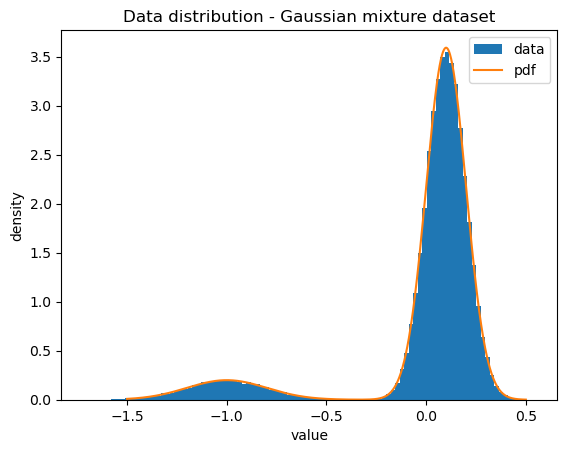

In [3]:
# Define Gaussian mixture dataset
points = torch.tensor([-1,0.1]).unsqueeze(-1)
weights = torch.tensor([0.1,0.9])
scale = torch.tensor([0.2,0.1])
# weights = torch.tensor([0.5,0.5])
# scale = torch.tensor([0.1,0.1])
nsamples = 100000
gaussian_dataset2 = diffsci.data.MixtureOfGaussiansDataset(num_samples=nsamples, means=points, weights=weights, scale=scale) 
gaussian_samples2 = gaussian_dataset2.sample()

# compute mean and std
mean = gaussian_samples2.mean()
std = gaussian_samples2.std()
print(f'Mean: {mean}')
print(f'std: {std}')

# choose dataset
data_ = gaussian_samples2
data = data_.squeeze(-1)
dataset = gaussian_dataset2
datatype = 'gaussian2'

# Plot the sampled distribution
bins = 100
plt.hist(gaussian_samples2.squeeze(-1), bins=bins, density=True, label='data')
plt.title("Data distribution - Gaussian mixture dataset")
plt.ylabel("density")
plt.xlabel("value")

# plot pdf
x = torch.linspace(-1.5, 0.5, 1000).unsqueeze(-1)
sigma = torch.zeros_like(x[..., 0])
pdf = gaussian_dataset2.prob(x, sigma)
plt.plot(x, pdf, label='pdf')
plt.legend()

torch.Size([1000, 1]) torch.Size([1000])


Text(0.5, 1.0, 'Score function - Gaussian mixture dataset')

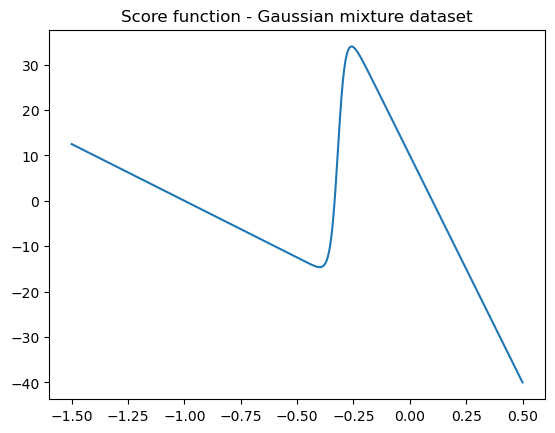

In [4]:
# plot score function
print(x.shape, sigma.shape)
score = gaussian_dataset2.gradlogprob(x, sigma)
plt.plot(x, score, label='score function ')
plt.title("Score function - Gaussian mixture dataset")

<!-- Define all functions -->

## Define all functions

In [5]:
# define diffusion prior
def prior_pdf(x, sigma):
    expterm = -0.5 * x**2 / sigma**2
    normalizer = 1/(np.sqrt(2*math.pi)*sigma)
    return normalizer * torch.exp(expterm)

# compute relative entropy for an aligned pair of densities (p, q) and a grid x
def relative_entropy(p, q, x, epsilon = 1e-15):
    # Avoid division by zero and log of zero
    p_values = torch.clip(p, epsilon, None)
    q_values = torch.clip(q, epsilon, None)

    x_size = abs(x[1] - x[0])
    dx = x_size.item()
    kl_divergence = torch.trapezoid(p_values * torch.log(p_values / q_values), dx=dx, dim=0)
    return kl_divergence

# standard way to format variables
def formatted(variable):
    if variable < 1e-3:
        formatted_variable = f'{variable:.2e}'
        formatted_variable = re.sub(r'e([-+]?)(\d+)', r' \\times 10^{\1\2}', formatted_variable)
    else:
        formatted_variable = f'{variable:.4f}'
    return formatted_variable

# compute the analytic entropy

def analytical_initial_entropy(dataset, initial_time, scheduler = diffsci.models.EDMScheduler(),
                               xlim = 3, ngrid =10000, plot = False, return_pdf=False, process = 'edm',
                               fontsize = 14, inverseH = False, ylim = None, prior_factor = 1):
    sigma = scheduler.scheduler_fns.noise_fn(torch.tensor(initial_time))
    scale = scheduler.scheduler_fns.scaling_fn(torch.tensor(initial_time))
    s = torch.tensor(sigma*scale)
    x = torch.linspace(-xlim, xlim,ngrid)
    x_ = x.unsqueeze(-1)
    p = prior_pdf(x_, s*prior_factor)
    q = dataset.prob(x_, sigma.unsqueeze(-1), scale.unsqueeze(-1))
    q = q.unsqueeze(-1)
    if inverseH:
        entropy = relative_entropy(q, p, x).item()
    else:
        entropy = relative_entropy(p, q, x).item()
    if plot:
        plt.plot(x, p, label='approx prior pdf')
        plt.plot(x, q, label='true prior pdf')
        plt.legend(fontsize=fontsize)
        if ylim is not None:
            plt.ylim(0, ylim)
        plt.title(f'Distributions at $t = {initial_time:.2f}$ ({process.upper()})', fontsize=fontsize+2)
        # Add a text box
        formatted_entropy = formatted(entropy)
        if inverseH:
            textstr = f'$H(p|\~p) = {formatted_entropy}$'
        else:
            textstr = f'Entropy value:\n$H_{{init}} = {formatted_entropy}$'
        plt.gca().text(0.025, 0.75, textstr, transform=plt.gca().transAxes, fontsize=fontsize,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
        plt.show()
    if return_pdf:
        return entropy, p, q, x
    else:
        return entropy


def approx_entropy(samples1, samples2, samples_ref, epsilon=1e-12, nbins=100, mean = True,
                   inverseH = False):
    entropies1 = []
    entropies2 = []
    for nb in range(nbins-20, nbins):
        if nb%4 == 0:
            continue
        min_value = torch.min(torch.tensor([samples1.min(), samples2.min(), samples_ref.min()]))
        max_value = torch.max(torch.tensor([samples1.max(), samples2.max(), samples_ref.max()]))
        dist = []
        bins = np.linspace(min_value, max_value, nb)
        for samples in [samples1, samples2, samples_ref]:
            hist = np.histogram(samples, bins=bins, density=True)[0]
            dist.append(hist+epsilon)
        if inverseH:
            entropy1 = entropy(dist[2], dist[0])
            entropy2 = entropy(dist[2], dist[1])
        else:
            entropy1 = entropy(dist[0], dist[2])
            entropy2 = entropy(dist[1], dist[2])
        entropies1.append(entropy1)
        entropies2.append(entropy2)
    if mean:
        entropy1 = np.mean(entropies1)
        entropy2 = np.mean(entropies2)
    else:
        entropy1 = np.min(entropies1)
        entropy2 = np.min(entropies2)
    return entropy1, entropy2

def approx_entropy1(samples, samples_ref, epsilon=1e-12, nbins=100):
    # Averaged the same way as approx_entropy: to reduce sensitivity to the
    # choice of nbins, we average the KL estimate over a range of bin counts.
    min_value = torch.min(torch.tensor([samples.min(), samples_ref.min()]))
    max_value = torch.max(torch.tensor([samples.max(), samples_ref.max()]))
    entropies = []
    for nb in range(nbins-20, nbins):
        if nb % 4 == 0:
            continue
        bins = np.linspace(min_value, max_value, nb)
        dist = []
        for s in [samples, samples_ref]:
            hist = np.histogram(s, bins=bins, density=True)[0]
            dist.append(hist+epsilon)
        entropies.append(entropy(dist[0], dist[1]))
    return np.mean(entropies)


def generate_samples(initial_step, gamma, nsteps, nsamples, dataset,
                     initial_p, exact_p,
                     interval=None,
                     sample_type='ode',
                     noisescheduler=diffsci.models.EDMScheduler(sigma_max=10),
                     scheduler_type= 'edm',
                     module=None,
                     use_exact_prior=False,
                     return_history=True,
                     checkpoint=None,
                     save_samples=True,
                     interp_fn = None,
                     integrator=diffsci.models.EulerIntegrator(),
                     analytical_score=dataset.gradlogprob,
                     plot=True):
    print(f'NoiseScheduler: {noisescheduler}')
    # set noise scheduler
    noisescheduler._integrator = integrator
    noisescheduler.langevin_const = gamma
    noisescheduler.langevin_interval = interval
    if module is not None:
        module.config.noisescheduler = noisescheduler
    
    # obtain initial time from initial step
    time = noisescheduler.create_steps(nsteps+1)
    initial_time_ = time[initial_step]
    initial_time = initial_time_.item() 

    prior_ = initial_p.squeeze(-1)
    exact_prior_ = exact_p.squeeze(-1)

    # plot prior distributions
    nbins = 100
    xlim = 5*sigma
    exact_initial_entropy, approx_dens, exact_dens, x = analytical_initial_entropy(
        dataset, initial_time, scheduler=noisescheduler, plot = False, return_pdf=True, xlim=xlim)
    print(f'Exact initial entropy = {exact_initial_entropy:.5f}')

    if plot:
        fig, ax = plt.subplots(1,2,figsize=(12,5))
        ax[0].hist(prior_, bins=nbins, density=True, alpha=0.5, label='independent prior', color='brown')
        ax[0].hist(exact_prior_, bins=nbins, density=True, alpha=0.5, color='green', label='exact prior')
        ax[0].set_title(f'Samples at time T={initial_time:.2f}')
        ax[0].xlim = xlim
        ax[0].legend()
        ax[1].plot(x, exact_dens, label='exact prior pdf')
        ax[1].plot(x, approx_dens, label='independent prior pdf')
        ax[1].set_title(f'Densities at time T={initial_time:.2f}')
        ax[1].legend()
        # text box
        formatted_intial_entropy = formatted(exact_initial_entropy)
        textstr = f'Entropy value:\n$H_{{init}} = {formatted_intial_entropy}$'
        ax[1].text(0.025, 0.95, textstr, transform=ax[1].transAxes, fontsize=12,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
        plt.show()

    # backward integration
    if use_exact_prior:
        prior = exact_p
    else:
        prior = initial_p
    
    if sample_type == 'ode':
        stochastic = False
    elif sample_type == 'sde':
        stochastic = True
        integrator = diffsci.models.EulerMaruyamaIntegrator()
    else:
        raise ValueError('Invalid sample_type')
    
    if module is not None:
        print('Sampling with learned scores, device: ', module.device)
        prior = prior.to(module.device)
        sample_history = module.propagate_partial_toward_sample(
             prior, initial_step=initial_step, nsteps=nsteps, record_history=True, integrator=integrator,
             analytical_score=analytical_score, interp_fn=interp_fn)
        sample_history = sample_history.cpu()
    else:
        sample_history = noisescheduler.propagate_partial(
            prior, analytical_score, nsteps, initial_step=initial_step, final_step=nsteps,
            record_history=True, stochastic=stochastic)
    
    # plot trajectory
    time = noisescheduler.create_steps(nsteps+1)
    trunc_time = time[initial_step:]
    nplot = 300
    if plot:
        fig = plt.figure(figsize=(8, 6))
        for i in range(nplot):
            x = sample_history[:, i].squeeze()
            plt.plot(trunc_time, x, color='black', linestyle='-', alpha=0.1)
        plt.xlabel("diffusion time", fontsize=14)
        plt.ylabel("value", fontsize=14)
        # plt.xlim([0, 1])
        plt.ylim([-3, 3])
        if sample_type == 'ode':
            plt.title(f'ODE trajectories ({scheduler_type.upper()})', fontsize=16)
        else:
            plt.title(f'SDE trajectories ($\gamma = {gamma}$)', fontsize=16)
        plt.show()

    if return_history:
        samples = sample_history.squeeze(-1)
    else:
        samples = sample_history[-1].squeeze(-1)

    # save data
    if save_samples:
        if module is not None:
            if checkpoint is None:
                raise ValueError('Checkpoint is required')
            path = pathlib.Path(checkpoint).parent.parent / 'saved_samples'
        else:
            raise ValueError('Module is required')
        path.mkdir(exist_ok=True)
        
        filename = f'nsamples={nsamples:.0e}-nsteps={nsteps}-T={initial_time:.3f}'
        if module is not None:
            filename = 'tr-' + filename
        else:
            filename = 'an-' + filename
        if use_exact_prior:
            filename = f'{sample_type}-exact_prior-' + filename
        else:
            filename = f'{sample_type}-indep_prior-' + filename
        if sample_type == 'sde':
            if interval is not None:
                filename += f'-g={gamma}-int={interval}'
            else:
                filename += f'-g={gamma}'
        if interp_fn is not None:
            filename += '-interp'
        
        if return_history:
            filename += '-his'            
        if scheduler_type == 'edm':
            filename += '-EDM'
        elif scheduler_type == 'vp':
            filename += '-VP'
        elif scheduler_type == 've':
            filename += '-VE'
        else:
            raise ValueError('Invalid scheduler_type')
        
        print(f'Saving samples to {path / filename}')
        torch.save(samples, path / filename)
    return samples


def plot_figure(samples_ode, samples_sde, data, gamma,
                initial_entropy=0, bound=None, initial_inv_entropy=0,
                nbins=100, title='Approximate prior and analytic scores', fontsize=14):
    # compute entropy
    ode_entropy, sde_entropy = approx_entropy(samples_ode, samples_sde, data, nbins=nbins)
    inv_ode_entropy, inv_sde_entropy = approx_entropy(samples_ode, samples_sde, data, nbins=nbins, inverseH=True)

    # plot
    fig = plt.figure(figsize=(8, 6))
    plt.hist(samples_ode, bins=nbins, density=True, alpha=0.5, label='ODE')
    plt.hist(samples_sde, bins=nbins, density=True, alpha=0.5, label=f'SDE ($\\gamma = {gamma:.1f}$)')
    plt.hist(data, bins=nbins, density=True, histtype='step', color='black', label='data')
    plt.ylabel("density", fontsize=fontsize)
    # plt.xlim(-1, 1)
    plt.legend(fontsize=fontsize)
    plt.title(title, fontsize=fontsize+2)

    # Add a text box
    textstr = (f'\n$H(\~p|p)_{{ODE}} = {ode_entropy:.4f}$ \n'
                + f'$H(\~p|p)_{{SDE}} = {sde_entropy:.4f}$ \n\n'
                + f'$H(p|\~p)_{{ODE}} = {inv_ode_entropy:.4f}$ \n'
                + f'$H(p|\~p)_{{SDE}} = {inv_sde_entropy:.4f}$ \n'
                + f'($n_{{bins}} = {nbins}$)')
    if initial_inv_entropy !=0:
        formatted_initial_inv_entropy = formatted(initial_inv_entropy)
        textstr = f'$H(p|\~p)_{{init}} = {formatted_initial_inv_entropy}$\n' + textstr
    if initial_entropy !=0:
        formatted_initial_entropy = formatted(initial_entropy)
        textstr = f'$H(\~p|p)_{{init}} = {formatted_initial_entropy}$\n' + textstr
    textstr = 'KL divergence values:\n' + textstr
    if bound is not None and bound != 0:
        textstr += f'\n \n bound: {bound:.4f}'
    plt.gca().text(0.025, 0.65, textstr, transform=plt.gca().transAxes, fontsize=fontsize,
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))


def compute_entropy_evolution(ode_history, sde_history, diffused_history, time,  mean=True, nbins=100,
                              inverseH=False):

    ode_entropies = []
    sde_entropies = []
    ode_wdistances = []
    sde_wdistances = []
    nsteps = time.shape[0]
    for i in range(nsteps):
        ode_entropy, sde_entropy = approx_entropy(ode_history[i], sde_history[i], diffused_history[i],
                                                  nbins=nbins, mean=mean, inverseH=inverseH)
        ode_entropies.append(ode_entropy)
        sde_entropies.append(sde_entropy)
    return ode_entropies, sde_entropies

def plot_entropy_evolution(ode_entropies, sde_entropies, time, gamma, initial_time,
                           initial_entropy=0,
                           inv_ode_entropies=None,
                           inv_sde_entropies=None,
                           bound_history=None,  # example: [[bound_his, delta], ...]
                           exact_score=False,
                           invH=False,
                           nbins=100,
                           title='Entropy evolution, approximate prior and analytic scores',
                           x_logscale=False, y_logscale=False, ylim=None, fontsize=16):
    from matplotlib.lines import Line2D

    fig, ax = plt.subplots(figsize=(8, 6))
    _cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    colors = [_cycle[0], _cycle[1], _cycle[2]]  # match plot_figure ODE/SDE hist tones (tab:blue, tab:orange)

    def add_split_legend(ax, fontsize=None):
        legend_kwargs = {'fontsize': fontsize} if fontsize is not None else {}
        if bound_history is not None:
            method_handles = [
                Line2D([0], [0], color=colors[0], linewidth=2, linestyle='-', label='ODE'),
                Line2D([0], [0], color=colors[1], linewidth=2, linestyle='-', label=f'SDE ($\\gamma={gamma:.1f}$)'),
                Line2D([0], [0], color=colors[2], linewidth=2, linestyle='-', label=f'bound (SDE)'),
            ]
            kl_box_height = 0.75
        else:
            method_handles = [
                Line2D([0], [0], color=colors[0], linewidth=2, linestyle='-', label='ODE'),
                Line2D([0], [0], color=colors[1], linewidth=2, linestyle='-', label=f'SDE ($\\gamma={gamma:.1f}$)'),
            ]
            kl_box_height = 0.82
        method_legend = ax.legend(handles=method_handles, loc='upper right', **legend_kwargs)
        ax.add_artist(method_legend)

        has_inv = inv_ode_entropies is not None or inv_sde_entropies is not None
        if has_inv:
            kl_handles = [
                Line2D([0], [0], color='k', linewidth=2, linestyle='-', label=r'$H(\~p|p)$'),
                Line2D([0], [0], color='k', linewidth=2, linestyle='--', label=r'$H(p|\~p)$'),
            ]
            kl_legend = ax.legend(handles=kl_handles, loc='upper right', bbox_to_anchor=(1, kl_box_height), **legend_kwargs)
            ax.add_artist(kl_legend)

        extra_handles = []
        if initial_entropy != 0:
            extra_handles.append(
                Line2D([0], [0], color='k', linewidth=2, linestyle='-.', label='initial entropy')
            )
        if extra_handles:
            ax.legend(handles=extra_handles, loc='lower right', **legend_kwargs)

    ax.plot(time, ode_entropies, color=colors[0])
    ax.plot(time, sde_entropies, color=colors[1])
    if inv_ode_entropies is not None:
        ax.plot(time, inv_ode_entropies, linestyle='--', color=colors[0])
    if inv_sde_entropies is not None:
        ax.plot(time, inv_sde_entropies, linestyle='--', color=colors[1])
    if bound_history is not None:
        if exact_score or invH:
            ax.plot(time, bound_history, linestyle=':')
        else:
            for i, bound in enumerate(bound_history):
                if i == 1:
                    ax.plot(time, bound[0], linestyle='--', color=colors[2])
                else:
                    ax.plot(time, bound[0], linestyle='-', color=colors[2])
    if initial_entropy != 0:
        ax.hlines(initial_entropy, 0, initial_time, linestyle='-.')

    ax.set_xlabel("diffusion time", fontsize=fontsize)
    ax.set_ylabel(f"divergence ($n_{{bins}}={nbins}$)", fontsize=fontsize)
    if x_logscale:
        ax.set_xscale('log')
    if y_logscale:
        ax.set_yscale('log')
    if ylim is not None:
        ax.set_ylim(0, ylim)
    # ax.set_xlim(time[-1], time[0])
    add_split_legend(ax, fontsize=fontsize)
    ax.set_title(title, fontsize=fontsize + 4)
    plt.tight_layout()


def custom_spacing(min, max, N, alpha):
    min_alpha = min ** alpha
    max_alpha = max ** alpha
    lin_space = torch.linspace(min_alpha, max_alpha, N)
    gamma_values = lin_space ** (1 / alpha)
    return gamma_values

def generate_multiple_gamma(initial_step, gamma_range, nsteps, nsamples, dataset, datatype,
                            ngamma=20,
                            interval=None,
                            noisescheduler=diffsci.models.EDMScheduler(sigma_max=10),
                            module=None,
                            use_exact_prior=False,
                            return_history=True,
                            checkpoint=None,
                            alpha=0.5,
                            epoch=None,
                            prior_factor=1):
    # set noise scheduler
    noisescheduler._integrator = diffsci.models.EulerIntegrator()
    noisescheduler.langevin_interval = interval
    if module is not None:
        module.config.noisescheduler = noisescheduler
    
    # hack to obtain step from initial_time
    time = noisescheduler.create_steps(nsteps+1)
    initial_time = time[initial_step].item()
    print(f'Initial time: {initial_time}')

    # generate prior distribution
    dataset.num_samples = nsamples
    samples = dataset.sample()
    sigma = noisescheduler.scheduler_fns.noise_fn(initial_time)
    prior = torch.randn_like(samples) * sigma * prior_factor
    exact_prior = noisescheduler.apply_noise(samples, nsteps, initial_step)

    # backward integration
    if use_exact_prior:
        prior = exact_prior
    
    assert len(gamma_range) == 2
    gamma_values = custom_spacing(gamma_range[0], gamma_range[-1], ngamma, alpha)
    print(f'Gamma values: {gamma_values}')

    if module is not None:
        prior = prior.to(module.device)
        ode_sample_history = module.propagate_partial_toward_sample(prior, initial_step=initial_step, nsteps=nsteps,
                                                                    record_history=True,
                                                                    integrator=diffsci.models.EulerIntegrator())
        ode_sample_history = ode_sample_history.cpu()
        sde_sample_history_ = []
        for g in gamma_values:
            noisescheduler.langevin_const = g
            sde_sample_history = module.propagate_partial_toward_sample(prior, initial_step=initial_step, nsteps=nsteps,
                                                                        record_history=True,
                                                                        integrator=diffsci.models.EulerMaruyamaIntegrator())
            sde_sample_history_.append(sde_sample_history.cpu())
    else:
        ode_sample_history = noisescheduler.propagate_partial(prior, dataset.gradlogprob, nsteps, initial_step=initial_step,
                                                              final_step=nsteps, record_history=True, stochastic=False)
        sde_sample_history_ = []
        for g in gamma_values:
            noisescheduler.langevin_const = g
            sde_sample_history = noisescheduler.propagate_partial(prior, dataset.gradlogprob, nsteps, initial_step=initial_step,
                                                                  final_step=nsteps, record_history=True, stochastic=True)
            sde_sample_history_.append(sde_sample_history)

    # save data
    if module is not None:
        if checkpoint is None:
            raise ValueError('Checkpoint is required')
        path = pathlib.Path(checkpoint).parent.parent / 'saved_samples'
    else:
        raise ValueError('Module is required')
    path.mkdir(exist_ok=True)
    
    filename = f'grange={gamma_range}-{ngamma}-nsteps={nsteps}'
    if module is not None:
        filename = 'tr-' + filename
    else:
        filename = 'an-' + filename
    if use_exact_prior:
        filename = 'exact_p-' + filename
    else:
        filename = 'approx_p-' + filename
    
    if epoch is not None:
        filename = f'epoch={epoch}-' + filename
    
    if interval is not None:
        filename += f'-interval={interval}'
    
    if prior_factor != 1:
        filename += f'-pf={prior_factor}'
    
    if return_history:
        ode_samples = ode_sample_history
        sde_samples = sde_sample_history_
        filename += '-his'
    else:
        ode_samples = ode_sample_history[-1].squeeze(-1)
        sde_samples = [sde_sample_history[-1].squeeze(-1) for sde_sample_history in sde_sample_history_]
    filename = 'mult_gamma-' + filename
    filename += f'-a={alpha}'
    samples = [ode_samples, sde_samples]
    torch.save(samples, path / filename)
    return samples


def plot_multiple_gamma(samples, diffused_data, gamma_range, initial_time, nsteps, ngamma=20,
                        initial_entropy=None, nbins=100, title='Approximate prior and analytic scores'):
    
    # compute entropy
    assert len(gamma_range) == 2
    gamma_values = torch.linspace(gamma_range[0], gamma_range[-1], ngamma)
    ode_samples, sde_samples = samples

    ode_entropy = approx_entropy1(ode_samples, diffused_data, nbins=nbins)
    sde_entropies = []
    for sde_sample in sde_samples:
        sde_entropy = approx_entropy1(sde_sample, diffused_data, nbins=nbins)
        sde_entropies.append(sde_entropy)

    # plot
    fig = plt.figure(figsize=(8, 6))
    plt.plot(gamma_values, sde_entropies, label='$H_{SDE}$')
    plt.hlines(ode_entropy, gamma_range[0], gamma_range[-1], label='$H_{ODE}$', linestyle='-.')
    if initial_entropy is not None:
        plt.hlines(initial_entropy, gamma_range[0], gamma_range[-1], label='initial entropy', linestyle='--')
        max_entropy = max(initial_entropy, ode_entropy)
    else:
        max_entropy = ode_entropy
        
    plt.xlabel("$\gamma$")
    plt.ylabel(f"entropy values \n $n_{{bins}}={nbins}$")
    plt.ylim(0, 2*max_entropy)
    plt.legend()
    plt.title(title + f', $T={initial_time:.2f}$, $nsteps={nsteps}$')


def plot_multiple_gamma2(data: list,
                        diffused_data, initial_time,
                        initial_entropy=None, nbins=100, alpha=0.5,
                        xlim=None, ylim=None, plot_scaling=True, xlog=False, ylog=False,
                        title='Approximate prior and analytic scores',
                        both_entropies=False,
                        legend_name=None,
                        colors=['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan'],
                        kl_place=(1, 0.7),
                        show_nsteps=True):
    from matplotlib.lines import Line2D

    # plot
    if plot_scaling:
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    else:
        fig, axs = plt.subplots(1, 1, figsize=(6, 5))
    max_entropy = 0
    gamma_max = 0
    gamma_min = 1e10
    scaled_gamma_max = 0
    scaled_gamma_min = 1e10
    all_entropies = []
    model_labels = []

    def add_split_legend(ax, fontsize=None):
        legend_kwargs = {'fontsize': fontsize} if fontsize is not None else {}
        model_handles = [
            Line2D([0], [0], color=colors[i], linewidth=2, linestyle='-', label=label)
            for i, label in enumerate(model_labels)
        ]
        if legend_name is not None:
            model_legend = ax.legend(handles=model_handles, loc='upper right',
                                    title=legend_name, title_fontsize=14, **legend_kwargs)
        else:
            model_legend = ax.legend(handles=model_handles, loc='upper right', **legend_kwargs)
        ax.add_artist(model_legend)
        if both_entropies:
            kl_handles = [
                Line2D([0], [0], color='k', linewidth=2, linestyle='-', label=r'$H(\~p|p)$'),
                Line2D([0], [0], color='k', linewidth=2, linestyle='--', label=r'$H(p|\~p)$'),
            ]
            kl_legend = ax.legend(handles=kl_handles, loc='upper right', 
                                  bbox_to_anchor=kl_place, **legend_kwargs)
            ax.add_artist(kl_legend)
        if initial_entropy is not None and initial_entropy != 0:
            init_handle = Line2D([0], [0], color='k', linewidth=2, linestyle=':', label='initial entropy')
            ax.legend(handles=[init_handle], loc='lower right', **legend_kwargs)

    for i, item in enumerate(data):
        samples, gamma_range, ngamma, nsteps, label = item
        ode_samples, sde_samples = samples
        model_labels.append(label)
        assert len(gamma_range) == 2
        gamma_values = custom_spacing(gamma_range[0], gamma_range[-1], ngamma, alpha)

        # ode_entropy = approx_entropy1(ode_samples, diffused_data, nbins=nbins)
        sde_entropies = []
        for sde_sample in sde_samples:
            sde_entropy = approx_entropy1(sde_sample, diffused_data, nbins=nbins)
            sde_entropies.append(sde_entropy)
        if both_entropies:
            inv_sde_entropies = []
            for sde_sample in sde_samples:
                inv_sde_entropy = approx_entropy1(diffused_data, sde_sample, nbins=nbins)
                inv_sde_entropies.append(inv_sde_entropy)
            all_entropies.append((gamma_values, sde_entropies, inv_sde_entropies))
        else:
            all_entropies.append(gamma_values, sde_entropies)
        
        # plot
        scaled_gamma = gamma_values / nsteps
        if plot_scaling:
            axs[0].plot(gamma_values, sde_entropies, alpha=0.8, color=colors[i])
            axs[1].plot(scaled_gamma, sde_entropies, alpha=0.8, color=colors[i])
        else:
            axs.plot(gamma_values, sde_entropies, alpha=0.8, color=colors[i])
        if both_entropies:
            if plot_scaling:
                axs[0].plot(gamma_values, inv_sde_entropies, alpha=0.8, linestyle='--', color=colors[i])
                axs[1].plot(scaled_gamma, inv_sde_entropies, alpha=0.8, linestyle='--', color=colors[i])
            else:
                axs.plot(gamma_values, inv_sde_entropies, alpha=0.8, linestyle='--', color=colors[i])

        gamma_max = max(gamma_max, gamma_range[-1])
        gamma_min = min(gamma_min, gamma_range[0])
        scaled_gamma_max = max(scaled_gamma_max, scaled_gamma[-1])
        scaled_gamma_min = min(scaled_gamma_min, scaled_gamma[0])
    
    if initial_entropy is not None and initial_entropy != 0:
        if plot_scaling:
            axs[0].hlines(initial_entropy, gamma_min, gamma_max, linestyle=':')
            axs[1].hlines(initial_entropy, scaled_gamma_min, scaled_gamma_max, linestyle=':')
        else:
            axs.hlines(initial_entropy, gamma_min, gamma_max, linestyle=':')
        max_entropy = max(max_entropy, initial_entropy)
    print(f'SDE entropy values: {sde_entropies}')
        
    if plot_scaling:
        axs[0].set_xlabel("$\gamma$")
        axs[1].set_xlabel("$\gamma/n_{steps}$")
        for ax in axs:
            ax.set_ylabel(f"divergence ($n_{{bins}}={nbins}$)")
            if ylim is not None:
                ax.set_ylim(0, ylim)
            else:
                ax.set_ylim(0, 2*max_entropy)
            add_split_legend(ax)
            ax.set_title(title + f', $T={initial_time:.2f}$')
        if xlim is not None:
            axs[0].set_xlim(0, xlim)
            axs[1].set_xlim(0, xlim/1000)
    else:
        axs.set_xlabel("$\gamma$", fontsize=14)
        axs.set_ylabel(f"divergence ($n_{{bins}}={nbins}$)", fontsize=14)
        if ylim is not None:
            axs.set_ylim(0, ylim)
        else:
            axs.set_ylim(0, 2*max_entropy)
            if xlim is not None:
                axs.set_xlim(0, xlim)
        add_split_legend(axs, fontsize=12)
        if show_nsteps:
            axs.set_title(title + f' ({nsteps} steps)', fontsize=16)
        else:
            axs.set_title(title, fontsize=16)
    if xlog:
        axs.set_xscale('log')
    if ylog:
        axs.set_yscale('log')
    fig.tight_layout()

    return all_entropies


# compute theorectical bound for the Gaussian mixture dataset

def c_gauss(t, m, p, sigma_data):           # this 't' is the forward time, which is in the following denoted by rev_t
    sigma = scheduler.scheduler_fns.noise_fn(torch.tensor(t))
    scale = scheduler.scheduler_fns.scaling_fn(torch.tensor(t))
    sigma2 = scale**2 * (sigma**2 + sigma_data**2)
    lamb = (np.log(p) - np.log(1 - p))/(2*p - 1)
    m2 = (scale * m)**2
    c = sigma2 * (1 + (p*(1 - p) * lamb * (np.exp(m2/sigma2) + 1)))
    return c

def c_gauss2(t, m, p, sigma_data):           # this 't' is the forward time, which is in the following denoted by rev_t
    sigma = scheduler.scheduler_fns.noise_fn(torch.tensor(t))
    scale = scheduler.scheduler_fns.scaling_fn(torch.tensor(t))
    sigma_0, sigma_1 = sigma_data
    sigma_0 = scale * np.sqrt(sigma**2 + sigma_0**2)
    sigma_1 = scale * np.sqrt(sigma**2 + sigma_1**2)
    m2 = (scale * m)**2
    # chi_0 = chi^2(mu_0 || mu_1) + 1, finite iff 2*sigma_1^2 > sigma_0^2
    if 2*sigma_1**2 - sigma_0**2 > 0:
        chi_0 = sigma_1**2/(sigma_0 * np.sqrt(2*sigma_1**2 - sigma_0**2)) * np.exp(m2/(2*sigma_1**2 - sigma_0**2))
    else:
        chi_0 = float('inf')
    # chi_1 = chi^2(mu_1 || mu_0) + 1, finite iff 2*sigma_0^2 > sigma_1^2
    if 2*sigma_0**2 - sigma_1**2 > 0:
        chi_1 = sigma_0**2/(sigma_1 * np.sqrt(2*sigma_0**2 - sigma_1**2)) * np.exp(m2/(2*sigma_0**2 - sigma_1**2))
    else:
        chi_1 = float('inf')
    if p == 0.5:
        lamb = 2
    else:
        lamb = (np.log(p) - np.log(1 - p))/(2*p - 1)
    # Schlichting (2019), Corollary 2:
    #   Case mu_0 << mu_1 (finite chi_0)
    c_0 = max(sigma_0**2 * (1 + (1-p)*lamb), sigma_1**2 * (1 + p*lamb*chi_0))
    #   Case mu_1 << mu_0 (finite chi_1)
    c_1 = max(sigma_1**2 * (1 + p*lamb),     sigma_0**2 * (1 + (1-p)*lamb*chi_1))
    c = min(c_0, c_1)
    if factor_c is not None:
        c = c * factor_c
    return c

def integrand(t, initial_time, m, p, sigma_data):
    rev_t = initial_time - t
    if process == 'edm':
        g2 = 2*rev_t
    elif process == 'vp':
        beta_min = 0.1
        beta_d = 19.9
        g2 = beta_d * rev_t + beta_min
    elif process == 've':
        g2 = 1
    if datatype == 'gaussian':
        c = c_gauss(rev_t, m, p, sigma_data)
    elif datatype == 'gaussian2':
        c = c_gauss2(rev_t, m, p, sigma_data)
    return 1/c * gamma * g2

def compute_integral(t_initial, t_final, initial_time, m, p, sigma_data):
    result, error = integrate.quad(integrand, t_initial, t_final, args=(initial_time, m, p, sigma_data))
    return result, error

<>:54: SyntaxWarning: invalid escape sequence '\~'
<>:212: SyntaxWarning: invalid escape sequence '\g'
<>:281: SyntaxWarning: invalid escape sequence '\~'
<>:282: SyntaxWarning: invalid escape sequence '\~'
<>:283: SyntaxWarning: invalid escape sequence '\~'
<>:284: SyntaxWarning: invalid escape sequence '\~'
<>:288: SyntaxWarning: invalid escape sequence '\~'
<>:291: SyntaxWarning: invalid escape sequence '\~'
<>:530: SyntaxWarning: invalid escape sequence '\g'
<>:636: SyntaxWarning: invalid escape sequence '\g'
<>:637: SyntaxWarning: invalid escape sequence '\g'
<>:650: SyntaxWarning: invalid escape sequence '\g'
<>:54: SyntaxWarning: invalid escape sequence '\~'
<>:212: SyntaxWarning: invalid escape sequence '\g'
<>:281: SyntaxWarning: invalid escape sequence '\~'
<>:282: SyntaxWarning: invalid escape sequence '\~'
<>:283: SyntaxWarning: invalid escape sequence '\~'
<>:284: SyntaxWarning: invalid escape sequence '\~'
<>:288: SyntaxWarning: invalid escape sequence '\~'
<>:291: Syntax

In [6]:
# create Scheduler class with EDM steps
class VEScheduler(diffsci.models.VEScheduler):
    def __init__(self,
                 sigma_min: float = 0.002,
                 sigma_max: float = 100,
                 expoent_steps: float = 7.0,
                 scheduler_fns = "VE",
                 *args,
                 **kwargs):
        super().__init__(sigma_min,
                         sigma_max,
                         scheduler_fns,
                         *args,
                         **kwargs)
        self._integrator = diffsci.models.EulerIntegrator()
        self.register_buffer("expoent_steps", torch.tensor(expoent_steps))
    
    def create_steps(self, n: int):
        s = torch.arange(n-1).to(self.expoent_steps)/(n-2)
        start = self.sigma_max**(1/self.expoent_steps)
        end = self.sigma_min**(1/self.expoent_steps)
        steps = (start + s*(end - start))**(self.expoent_steps)
        if not self.scheduler_fns.identity_noise_fn:
            steps = self.scheduler_fns.inverse_noise_fn(steps)
        steps = torch.cat([steps, torch.zeros([1]).to(steps)])
        return steps

    def step_from_time(self, t, n: int):
        exp = 1/self.expoent_steps
        sigma = self.scheduler_fns.noise_fn(t)
        step = (n-1) * (sigma**(exp) - self.sigma_max**(exp)) / (self.sigma_min**(exp) - self.sigma_max**(exp))
        return torch.round(step).int()


class VPScheduler(diffsci.models.VPScheduler):
    def __init__(self,
                 epsilon_min: float = 0.001,
                 expoent_steps: float = 7.0,
                 sigma_min: float = 0.002,
                 sigma_max: float = 20.0,
                 scheduler_fns = "VP",
                 *args,
                 **kwargs):
        super().__init__(epsilon_min,
                         scheduler_fns,
                         *args,
                         **kwargs)
        self._integrator = diffsci.models.EulerIntegrator()
        self.register_buffer("expoent_steps", torch.tensor(expoent_steps))
        self.register_buffer("sigma_min", torch.tensor(sigma_min))
        self.register_buffer("sigma_max", torch.tensor(sigma_max))
    
    def create_steps(self, n: int):
        s = torch.arange(n-1).to(self.expoent_steps)/(n-2)
        start = self.sigma_max**(1/self.expoent_steps)
        end = self.sigma_min**(1/self.expoent_steps)
        steps = (start + s*(end - start))**(self.expoent_steps)
        if not self.scheduler_fns.identity_noise_fn:
            steps = self.scheduler_fns.inverse_noise_fn(steps)
        steps = torch.cat([steps, torch.zeros([1]).to(steps)])
        return steps

    def step_from_time(self, t, n: int):
        exp = 1/self.expoent_steps
        sigma = self.scheduler_fns.noise_fn(t)
        step = (n-1) * (sigma**(exp) - self.sigma_max**(exp)) / (self.sigma_min**(exp) - self.sigma_max**(exp))
        return torch.round(step).int()

## Learned score functions

In [7]:
# set cuda visible device
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

Define trainable module

In [8]:
import lightning
import lightning.pytorch.callbacks as callbacks
import lightning.pytorch.loggers as pl_loggers

from diffsci.models import KarrasModule, KarrasModuleConfig

import torch.nn as nn
import math

class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        # t shape: [batch_size]
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

class Improved1DMLP(nn.Module):
    def __init__(self, data_dim=1, time_embed_dim=64, hidden_dim=128, num_layers=3, residual=True):
        """
        A residual MLP with sinusoidal time embeddings and layer-wise time injection.
        """
        super().__init__()
        
        # 1. Time Embedding Pipeline
        self.time_embed = SinusoidalEmbedding(time_embed_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_embed_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        
        # 2. Input Projection
        self.input_proj = nn.Linear(data_dim, hidden_dim)
        
        # 3. Residual Layers
        self.layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.SiLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ) for _ in range(num_layers)
        ])
        
        # 4. Output Projection
        self.output_proj = nn.Linear(hidden_dim, data_dim)
        self.act = nn.SiLU()
        self.residual = residual

    def forward(self, x, t):
        """
        x : [nbatch, 1] or [nbatch]
        t : [nbatch]
        """
        if x.ndim == 1:
            x = x.unsqueeze(-1)

        # Process Time
        t_emb = self.time_mlp(self.time_embed(t)) # [nbatch, hidden_dim]

        # Process Spatial Data
        h = self.input_proj(x)

        # Pass through residual blocks
        for layer in self.layers:
            # Inject time via addition before the block's non-linearity
            h = h + t_emb 
            # Residual connection
            if self.residual:
                h = h + layer(self.act(h))
            else:
                h = layer(self.act(h))

        return self.output_proj(h)

In [9]:
from diffsci.models import NoiseSampler

class EDMNoiseSampler_mod(NoiseSampler):
    def __init__(self, sigma_data = 0.5, prior_mean = -1.2, prior_std = 1.2):
        super().__init__()
        self.register_buffer("sigma_data", torch.tensor(sigma_data))
        self.register_buffer("prior_mean", torch.tensor(prior_mean))
        self.register_buffer("prior_std", torch.tensor(prior_std))

    def loss_weighting(self, sigma):
        return (sigma**2 + self.sigma_data**2)/((sigma*self.sigma_data)**3)

    def sample(self, shape):
        white_noise = torch.randn(shape).to(self.prior_mean.device)
        logsigma = white_noise*self.prior_std + self.prior_mean
        sigma = torch.exp(logsigma)
        return sigma
    
from diffsci.models import EDMPreconditioner

class CustomEDMPreconditioner(EDMPreconditioner):
    def __init__(self, sigma_data = 0.5, mode = "scale"):
        super().__init__()
        self.register_buffer("sigma_data", torch.tensor(sigma_data))
        self.mode = mode
        
    def noise_conditioner(self, sigma):
        if self.mode == "default":
            return 0.5 * torch.log(sigma)
        elif self.mode == "scale":
            return 0.25 * torch.log(sigma)
        elif self.mode == "floor":
            return 0.5 * torch.log(sigma + 1e-2)
        else:
            raise ValueError(f"Invalid mode: {self.mode}")

In [10]:
preconditioner = "edm"
mode = "default"
width = 128

In [11]:
batch_size = 16     # default 16
nsamples_train = 4000
nsamples_test = 10000

dataset = gaussian_dataset2

points = torch.tensor([-1,0.1]).unsqueeze(-1)
weights = torch.tensor([0.1,0.9])
scale = torch.tensor([0.2,0.1])

g_data_train = diffsci.data.MixtureOfGaussiansDataset(num_samples=nsamples_train, means=points, weights=weights, scale=scale)
g_data_test = diffsci.data.MixtureOfGaussiansDataset(num_samples=nsamples_test, means=points, weights=weights, scale=scale)

train_dataset = g_data_train.sample()
test_dataset = g_data_test.sample()
num_workers = 0
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# model
assert preconditioner in ["edm", "vp", "ve"]
if preconditioner == "edm":
    # noise_log_mean = -2
    # config = KarrasModuleConfig.from_edm(prior_mean = noise_log_mean)
    config = KarrasModuleConfig.from_edm()
    config.preconditioner = CustomEDMPreconditioner(mode = mode)
    # config.noisesampler = EDMNoiseSampler_mod(prior_mean = noise_log_mean)
    
elif preconditioner == "vp":
    config = KarrasModuleConfig.from_vp()
elif preconditioner == "ve":
    config = KarrasModuleConfig.from_ve()

layers = [width, width, width]
residual = False
model = Improved1DMLP(data_dim=1, time_embed_dim=width//2, hidden_dim=width, num_layers=3, residual=residual)
# model = diffsci.models.MLPUncond(1, layers, nonlinearity=torch.nn.SiLU(), dropout=0.1)
module = KarrasModule(model, config)

# training parameters
learning_rate = 4e-2/width
module.optimizer = torch.optim.AdamW(module.parameters(),
                                    lr=learning_rate,)
module.lr_scheduler = None
num_epochs = 48
every_n_epochs = 1
# top_k = 3

Training

In [12]:
# set trainer
savefolderstr = f"mixt_gauss2_silu-width={width}-bs={batch_size}-precond={preconditioner}-diffsci-train={nsamples_train}-nlm=default8"
MODELSPATH = '/home/ubuntu/repos/DiffSci/savedmodels/experimental'
savedir = os.path.join(MODELSPATH, savefolderstr)

checkpoint_callback = callbacks.ModelCheckpoint(
        monitor='valid_loss',
        dirpath=os.path.join(savedir, 'checkpoints'),
        filename='sample-{epoch:02d}-{valid_loss:.6f}',
        every_n_epochs=every_n_epochs,
        save_top_k=-1,
        mode='min',
    )

tb_logger = pl_loggers.TensorBoardLogger(save_dir=savedir, name='logs')

trainer = lightning.Trainer(max_epochs=num_epochs,
                            logger=tb_logger,
                            callbacks=[checkpoint_callback],
                            fast_dev_run=False)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [13]:
# # train model

# trainer.fit(model=module,
#             train_dataloaders=train_dataloader,
#             val_dataloaders=test_dataloader)

Testing

In [14]:
# load model (substitute by your checkpointpath)

checkpointpath = r"/home/ubuntu/repos/DiffSci/savedmodels/production/mixt_gauss2_silu-width=128-bs=16-precond=edm-default-train=4000-nonres2/checkpoints/sample-epoch=43-valid_loss=0.290424.ckpt"
module = KarrasModule.load_from_checkpoint(model=model, config=config, checkpoint_path=checkpointpath)
datatype = 'gaussian2'

<!-- MULTIPLE GAMMA -->

In [15]:
# Parameters for sampling
process = 'edm'

if process == 'edm':
    scheduler = diffsci.models.EDMScheduler()
    initial_time=80
elif process == 'vp':
    scheduler = VPScheduler()
    initial_time=0.205
elif process == 've':
    scheduler = VEScheduler()
    initial_time=0.55
else:
    raise ValueError('Invalid process')

initial_time_ = torch.tensor(initial_time)
nsteps = 500
gamma = 1
nsamples = 100000
tnsamples = 100000
module.config.noisescheduler = scheduler
initial_step = scheduler.step_from_time(initial_time_, nsteps)
time = scheduler.create_steps(nsteps+1)
initial_time = time[initial_step].item()
gamma_max = 20
# interval = [0.02, 0.1]
interval = None

exact_prior = False
print(f'Initial step: {initial_step}')
print(f'Initial_time: {initial_time}')
print(f'Gamma max: {gamma_max}')
print(f'Interval: {interval}')

# generate prior distributions
dataset.num_samples = nsamples
samples = dataset.sample()
sigma = scheduler.scheduler_fns.noise_fn(initial_time_)
scale = scheduler.scheduler_fns.scaling_fn(initial_time_)
initial_p = torch.randn_like(samples) * sigma * scale
exact_p = scheduler.apply_noise(samples, nsteps, initial_step)

exact_prior = False

prior = 'approx_prior'
if exact_prior:
    exact_initial_entropy = 0
    prior = 'exact_prior'

# Generate data for comparison
tmin = time[-2]
print(f'Final time: {tmin}')
sigma_min = scheduler.scheduler_fns.noise_fn(tmin)
scale_min = scheduler.scheduler_fns.scaling_fn(tmin)
noise = torch.randn_like(gaussian_samples2) * sigma_min * scale_min

diffused_gdata2 = scale_min * gaussian_samples2 + noise
diffused_data = diffused_gdata2

Initial step: 0
Initial_time: 80.00001525878906
Gamma max: 20
Interval: None
Final time: 0.0019999996293336153


In [16]:
# epoch = 43
# prior_factor = 1
# samples = generate_multiple_gamma(initial_step, [0.01, gamma_max], nsteps, nsamples, dataset=dataset, datatype=datatype,
#                         ngamma=50, noisescheduler=scheduler, module=module, return_history=True,
#                         checkpoint=checkpointpath, use_exact_prior=exact_prior, epoch=epoch, interval=interval,
#                         prior_factor=prior_factor)

In [17]:
samples075_epoch43_path = r"/home/ubuntu/repos/DiffSci/savedmodels/production/mixt_gauss2_silu-width=128-bs=16-precond=edm-default-train=4000-nonres2/saved_samples/mult_gamma-epoch=43-approx_p-tr-grange=[0.01, 20]-50-pf=0.75-his-a=0.5"
sample_histories = torch.load(samples075_epoch43_path)
ode_history, sde_history_ = sample_histories
ode_samples075_epoch43 = ode_history[-1]
sde_samples075_epoch43_ = [sde_history[-1] for sde_history in sde_history_]
ode_samples075_epoch43.shape, sde_samples075_epoch43_[0].shape

samples12_epoch43_path = r"/home/ubuntu/repos/DiffSci/savedmodels/production/mixt_gauss2_silu-width=128-bs=16-precond=edm-default-train=4000-nonres2/saved_samples/mult_gamma-epoch=43-approx_p-tr-grange=[0.01, 20]-50-pf=1.2-his-a=0.5"
sample_histories = torch.load(samples12_epoch43_path)
ode_history, sde_history_ = sample_histories
ode_samples12_epoch43 = ode_history[-1]
sde_samples12_epoch43_ = [sde_history[-1] for sde_history in sde_history_]
ode_samples12_epoch43.shape, sde_samples12_epoch43_[0].shape

samples1_epoch43_path = r"/home/ubuntu/repos/DiffSci/savedmodels/production/mixt_gauss2_silu-width=128-bs=16-precond=edm-default-train=4000-nonres2/saved_samples/mult_gamma-epoch=43-approx_p-tr-grange=[0.01, 20]-50-his-a=0.5"
sample_histories = torch.load(samples1_epoch43_path)
ode_history, sde_history_ = sample_histories
ode_samples1_epoch43 = ode_history[-1]
sde_samples1_epoch43_ = [sde_history[-1] for sde_history in sde_history_]
ode_samples1_epoch43.shape, sde_samples1_epoch43_[0].shape

/tmp/ipykernel_3448972/3524182001.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample_histories = torch.load(samples075_epoch43_path)
/tmp/ipykernel_3448972/352418200

(torch.Size([100000, 1]), torch.Size([100000, 1]))

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3448972/2253507892.py:2: SyntaxWarning: invalid escape sequence '\s'
  ([ode_samples075_epoch43, sde_samples075_epoch43_], [0.01, 20], 50, 500, '$\sigma(T)=60$'),
/tmp/ipykernel_3448972/2253507892.py:3: SyntaxWarning: invalid escape sequence '\s'
  ([ode_samples1_epoch43, sde_samples1_epoch43_], [0.01, 20], 50, 500, '$\sigma(T)=80$ (default)'),
/tmp/ipykernel_3448972/2253507892.py:4: SyntaxWarning: invalid escape sequence '\s'
  ([ode_samples12_epoch43, sde_samples12_epoch43_], [0.01, 20], 50, 500, '$\sigma(T)=100$')


SDE entropy values: [np.float64(0.11911191271367359), np.float64(0.08262841262107434), np.float64(0.051725042964794604), np.float64(0.03243407533717708), np.float64(0.021856214683950433), np.float64(0.015930839474903157), np.float64(0.014571698056668017), np.float64(0.012762561745596389), np.float64(0.013542614567439217), np.float64(0.011770581447000139), np.float64(0.011654717473799762), np.float64(0.011071446489496047), np.float64(0.009911803497941624), np.float64(0.009277636577099404), np.float64(0.01024967034338445), np.float64(0.009927734103988638), np.float64(0.009077764228026534), np.float64(0.010588306107114476), np.float64(0.010246436606826637), np.float64(0.011837794833161242), np.float64(0.010101090396317212), np.float64(0.00975826598860354), np.float64(0.009541813550231969), np.float64(0.011025057754020882), np.float64(0.010448498289092159), np.float64(0.012046879127454602), np.float64(0.011684893797538816), np.float64(0.012472569201064229), np.float64(0.011640499725571978)

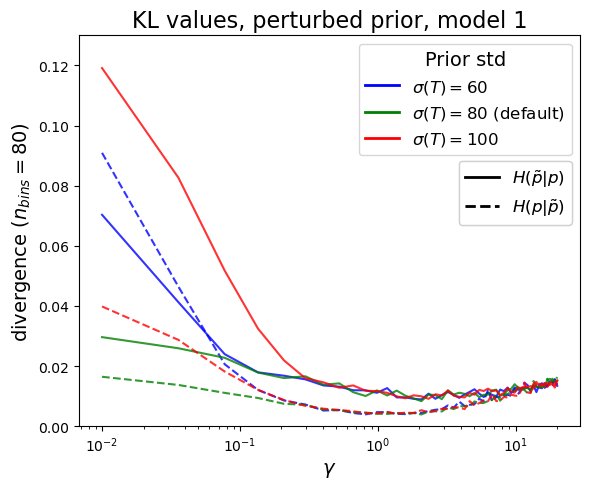

In [18]:
data = [
        ([ode_samples075_epoch43, sde_samples075_epoch43_], [0.01, 20], 50, 500, '$\sigma(T)=60$'),
        ([ode_samples1_epoch43, sde_samples1_epoch43_], [0.01, 20], 50, 500, '$\sigma(T)=80$ (default)'),
        ([ode_samples12_epoch43, sde_samples12_epoch43_], [0.01, 20], 50, 500, '$\sigma(T)=100$')
]

title = 'KL values, perturbed prior, model 1'
exact_initial_entropy = None
legend_name = 'Prior std'
colors = ['blue', 'green', 'red']

all_entropies = plot_multiple_gamma2(data, diffused_data, initial_time, initial_entropy=exact_initial_entropy,
    nbins=80, plot_scaling=False, ylim=0.13, xlog=True, title=title, both_entropies=True,
    legend_name=legend_name, colors=colors, show_nsteps=False)

In [25]:
samples50_epoch43_path = r"/home/ubuntu/repos/DiffSci/savedmodels/production/mixt_gauss2_silu-width=128-bs=16-precond=edm-default-train=4000-nonres2/saved_samples/mult_gamma-epoch=43-approx_p-tr-grange=[0.01, 20]-50-nsteps=50-his-a=0.5"
sample_histories = torch.load(samples50_epoch43_path)
ode_history, sde_history_ = sample_histories
ode_samples50_epoch43 = ode_history[-1]
sde_samples50_epoch43_ = [sde_history[-1] for sde_history in sde_history_]
ode_samples50_epoch43.shape, sde_samples50_epoch43_[0].shape

samples100_epoch43_path = r"/home/ubuntu/repos/DiffSci/savedmodels/production/mixt_gauss2_silu-width=128-bs=16-precond=edm-default-train=4000-nonres2/saved_samples/mult_gamma-epoch=43-approx_p-tr-grange=[0.01, 20]-50-nsteps=100-his-a=0.5"
sample_histories = torch.load(samples100_epoch43_path)
ode_history, sde_history_ = sample_histories
ode_samples100_epoch43 = ode_history[-1]
sde_samples100_epoch43_ = [sde_history[-1] for sde_history in sde_history_]
ode_samples100_epoch43.shape, sde_samples100_epoch43_[0].shape

samples200_epoch43_path = r"/home/ubuntu/repos/DiffSci/savedmodels/production/mixt_gauss2_silu-width=128-bs=16-precond=edm-default-train=4000-nonres2/saved_samples/mult_gamma-epoch=43-approx_p-tr-grange=[0.01, 20]-50-nsteps=200-his-a=0.5"
sample_histories = torch.load(samples200_epoch43_path)
ode_history, sde_history_ = sample_histories
ode_samples200_epoch43 = ode_history[-1]
sde_samples200_epoch43_ = [sde_history[-1] for sde_history in sde_history_]
ode_samples200_epoch43.shape, sde_samples200_epoch43_[0].shape

samples500_epoch43_path = r"/home/ubuntu/repos/DiffSci/savedmodels/production/mixt_gauss2_silu-width=128-bs=16-precond=edm-default-train=4000-nonres2/saved_samples/mult_gamma-epoch=43-approx_p-tr-grange=[0.01, 20]-50-nsteps=500-his-a=0.5"
sample_histories = torch.load(samples500_epoch43_path)
ode_history, sde_history_ = sample_histories
ode_samples500_epoch43 = ode_history[-1]
sde_samples500_epoch43_ = [sde_history[-1] for sde_history in sde_history_]
ode_samples500_epoch43.shape, sde_samples500_epoch43_[0].shape

samples1000_epoch43_path = r"/home/ubuntu/repos/DiffSci/savedmodels/production/mixt_gauss2_silu-width=128-bs=16-precond=edm-default-train=4000-nonres2/saved_samples/mult_gamma-epoch=43-approx_p-tr-grange=[0.01, 20]-50-nsteps=1000-his-a=0.5"
sample_histories = torch.load(samples1000_epoch43_path)
ode_history, sde_history_ = sample_histories
ode_samples1000_epoch43 = ode_history[-1]
sde_samples1000_epoch43_ = [sde_history[-1] for sde_history in sde_history_]
ode_samples1000_epoch43.shape, sde_samples1000_epoch43_[0].shape

/tmp/ipykernel_338593/1473171167.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample_histories = torch.load(samples50_epoch43_path)
/tmp/ipykernel_338593/1473171167.p

(torch.Size([100000, 1]), torch.Size([100000, 1]))

SDE entropy values: [np.float64(0.029533555810549082), np.float64(0.025255914785248287), np.float64(0.02261812307849004), np.float64(0.0194431244415811), np.float64(0.01737136666865454), np.float64(0.014875268004626897), np.float64(0.014277492030227724), np.float64(0.009507792078464715), np.float64(0.009883453407920314), np.float64(0.008371202819286334), np.float64(0.009012014491914152), np.float64(0.00840391201441691), np.float64(0.00832679409697525), np.float64(0.00864489537773424), np.float64(0.007323543115644552), np.float64(0.008395000070906797), np.float64(0.007984528853664552), np.float64(0.009807125613816046), np.float64(0.0074687777220404225), np.float64(0.008373099423843908), np.float64(0.007690836342944081), np.float64(0.007566041013794191), np.float64(0.008700620586422512), np.float64(0.009484561031714878), np.float64(0.008338271391689769), np.float64(0.009160650657381296), np.float64(0.009294856790653151), np.float64(0.010272861294048518), np.float64(0.00987757207480126), 

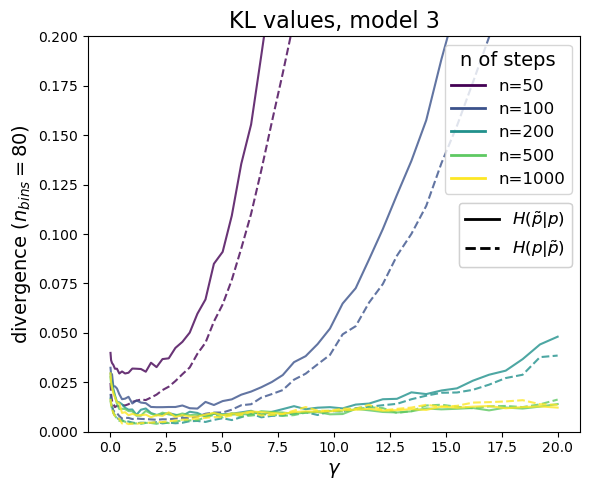

In [26]:
data = [
    ([ode_samples50_epoch43, sde_samples50_epoch43_], [0.01, 20], 50, 50, 'n=50'),
    ([ode_samples100_epoch43, sde_samples100_epoch43_], [0.01, 20], 50, 100, 'n=100'),
    ([ode_samples200_epoch43, sde_samples200_epoch43_], [0.01, 20], 50, 200, 'n=200'),
    ([ode_samples500_epoch43, sde_samples500_epoch43_], [0.01, 20], 50, 500, 'n=500'),
    ([ode_samples1000_epoch43, sde_samples1000_epoch43_], [0.01, 20], 50, 1000, 'n=1000'),
]

title = 'KL values, model 3'
exact_initial_entropy = None
colors = plt.cm.viridis(np.linspace(0, 1, len(data)))
kl_place = (1, 0.6)

all_entropies = plot_multiple_gamma2(data, diffused_data, initial_time, initial_entropy=exact_initial_entropy,
    nbins=80, plot_scaling=False, ylim=0.2, legend_name='n of steps',
    title=title, both_entropies=True, colors=colors, kl_place=kl_place, show_nsteps=False)

/tmp/ipykernel_3448972/3816244817.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample_histories = torch.load(samples2_epoch47_path)
/tmp/ipykernel_3448972/3816244817.

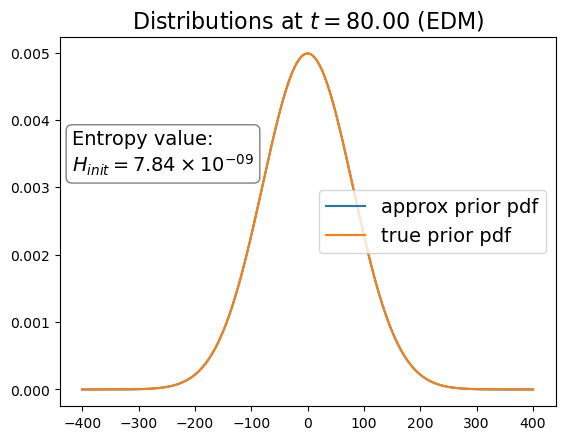

In [19]:
samples2_epoch47_path = r"/home/ubuntu/repos/DiffSci/savedmodels/experimental/mixt_gauss2_silu-width=128-bs=16-precond=edm-diffsci-train=4000-nlm=default2/saved_samples/mult_gamma-epoch=47-approx_p-tr-grange=[0.01, 20]-50-nsteps=500-his-a=0.5"
sample_histories = torch.load(samples2_epoch47_path)
ode_history, sde_history_ = sample_histories
ode_samples2_epoch47 = ode_history[-1]
sde_samples2_epoch47_ = [sde_history[-1] for sde_history in sde_history_]
ode_samples2_epoch47.shape, sde_samples2_epoch47_[0].shape

samples_epoch41_path = r"/home/ubuntu/repos/DiffSci/savedmodels/experimental/mixt_gauss2_silu-width=128-bs=16-precond=edm-diffsci-train=4000-nlm=default/saved_samples/mult_gamma-epoch=41-approx_p-tr-grange=[0.01, 20]-50-his-a=0.5"
sample_histories = torch.load(samples_epoch41_path)
ode_history, sde_history_ = sample_histories
ode_samples_epoch41 = ode_history[-1]
sde_samples_epoch41_ = [sde_history[-1] for sde_history in sde_history_]
ode_samples_epoch41.shape, sde_samples_epoch41_[0].shape

samples500_epoch43_path = r"/home/ubuntu/repos/DiffSci/savedmodels/production/mixt_gauss2_silu-width=128-bs=16-precond=edm-default-train=4000-nonres2/saved_samples/mult_gamma-epoch=43-approx_p-tr-grange=[0.01, 20]-50-nsteps=500-his-a=0.5"
sample_histories = torch.load(samples500_epoch43_path)
ode_history, sde_history_ = sample_histories
ode_samples500_epoch43 = ode_history[-1]
sde_samples500_epoch43_ = [sde_history[-1] for sde_history in sde_history_]
ode_samples500_epoch43.shape, sde_samples500_epoch43_[0].shape

sigma = scheduler.scheduler_fns.noise_fn(initial_time_)
xlim = 5*sigma
if exact_prior:
    exact_initial_entropy = None
else:
    exact_initial_entropy = analytical_initial_entropy(dataset, initial_time, scheduler=scheduler, plot=True, xlim=xlim)

SDE entropy values: [np.float64(0.028728391188177247), np.float64(0.024595457726713132), np.float64(0.022829130985914006), np.float64(0.023504522372919907), np.float64(0.01973329136480633), np.float64(0.014718399652368748), np.float64(0.013622372840574732), np.float64(0.01356546555787847), np.float64(0.013158829477536639), np.float64(0.01074277792059595), np.float64(0.009568175754421489), np.float64(0.011382882869987988), np.float64(0.00862851225346126), np.float64(0.012334411395504256), np.float64(0.011238996191803595), np.float64(0.009435319595794191), np.float64(0.012424142872516013), np.float64(0.010789527917877954), np.float64(0.011300969399560266), np.float64(0.01056802437444624), np.float64(0.010283256593674368), np.float64(0.009953743858005586), np.float64(0.00954719120926344), np.float64(0.009636957325250634), np.float64(0.010866309510129093), np.float64(0.009855832263861306), np.float64(0.011217414666343187), np.float64(0.010878833398254639), np.float64(0.013040230163474302),

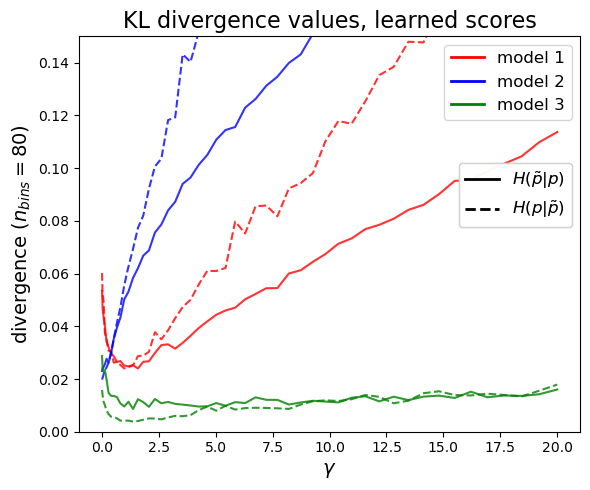

In [21]:
data = [
        ([ode_samples_epoch41, sde_samples_epoch41_], [0.01, 20], 50, 500, 'model 1'),
        ([ode_samples2_epoch47, sde_samples2_epoch47_], [0.01, 20], 50, 500, 'model 2'),
        ([ode_samples500_epoch43, sde_samples500_epoch43_], [0.01, 20], 50, 500, 'model 3'),
]

title = 'KL divergence values, learned scores'
exact_initial_entropy = None

all_entropies = plot_multiple_gamma2(data, diffused_data, initial_time, initial_entropy=exact_initial_entropy,
    nbins=80, plot_scaling=False, ylim=0.15, title=title, both_entropies=True, show_nsteps=False)

<!-- VISUALIZE EARLY-TRAINING AND LATE-TRAINING SCORE FNS ACROSS TIME -->

Error norms

Initial step: 0
Initial_time: 80.00001525878906


/tmp/ipykernel_338593/2472915332.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s = torch.tensor(sigma*scale)


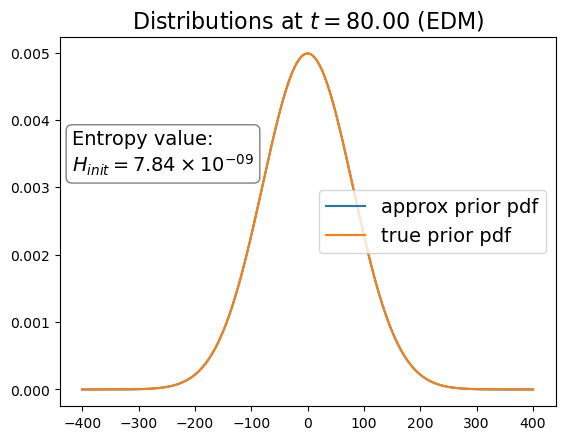

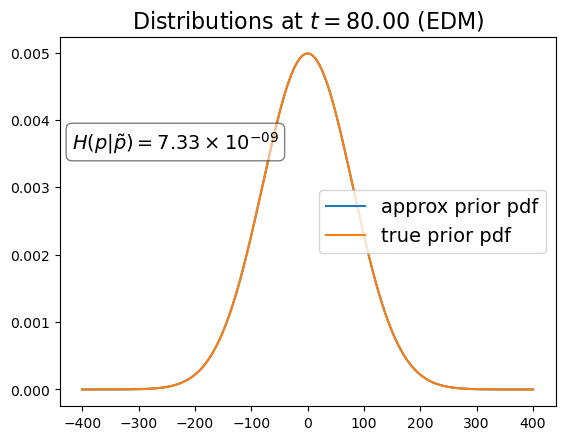

In [32]:
# Define parameters
process = 'edm'

if process == 'edm':
    scheduler = diffsci.models.EDMScheduler()
    initial_time=80
elif process == 'vp':
    scheduler = VPScheduler()
    initial_time=0.205
elif process == 've':
    scheduler = VEScheduler()
    initial_time=0.55
else:
    raise ValueError('Invalid process')

initial_time_ = torch.tensor(initial_time)
nsteps = 500
gamma = 1
nsamples = 100000

initial_step = scheduler.step_from_time(t=initial_time_, n=nsteps)
time = scheduler.create_steps(nsteps+1)
initial_time = time[initial_step].item()
print(f'Initial step: {initial_step}')
print(f'Initial_time: {initial_time}')

# choose dataset
data_ = gaussian_samples2
data = data_.squeeze(-1)
dataset = gaussian_dataset2
datatype = 'gaussian2'

interval = None
# interval = [0.1, 1.0]

sigma = scheduler.scheduler_fns.noise_fn(initial_time_)
xlim = 5*sigma
exact_initial_entropy = analytical_initial_entropy(dataset, initial_time, scheduler=scheduler, plot=True, xlim=xlim, process=process)
inv_initial_entropy = analytical_initial_entropy(dataset, initial_time, scheduler=scheduler, plot=True, xlim=xlim, process=process, inverseH=True)

In [33]:
# Generate data for comparison
tmin = time[-2]
print(f'Final time: {tmin}')
sigma_min = scheduler.scheduler_fns.noise_fn(tmin)
scale_min = scheduler.scheduler_fns.scaling_fn(tmin)
noise = torch.randn_like(gaussian_samples2) * sigma_min * scale_min

# diffused_gdata2 = scale_min * gaussian_samples2 + noise
# diffused_data = gaussian_samples2

# temporarily change gamma to 1
scheduler.langevin_const = 1

history_steps = nsteps+1-initial_step
forw_sde_history = scheduler.propagate_forward(gaussian_samples2, dataset.gradlogprob, nsteps, record_history=True, stochastic=True)
print(forw_sde_history.shape)
forw_sde_history = forw_sde_history.cpu()
forw_sde_his = forw_sde_history[:history_steps].squeeze(-1)
forw_sde_his = forw_sde_his.flip(0)
forw_sde_his[-1] = data
forw_sde_his.shape

# unchange gamma
scheduler.langevin_const = gamma

Final time: 0.0019999996293336153
torch.Size([501, 100000, 1])


In [34]:
# generate prior distributions
dataset.num_samples = nsamples
samples = dataset.sample()
sigma = scheduler.scheduler_fns.noise_fn(initial_time_)
scale = scheduler.scheduler_fns.scaling_fn(initial_time_)
initial_p = torch.randn_like(samples) * sigma * scale
exact_p = scheduler.apply_noise(samples, nsteps, initial_step)

exact_prior = False

prior = 'approx_prior'
if exact_prior:
    exact_initial_entropy = 0
    prior = 'exact_prior'

In [35]:
checkpointpath1 = r"/home/ubuntu/repos/DiffSci/savedmodels/experimental/mixt_gauss2_silu-width=128-bs=16-precond=edm-diffsci-train=4000-nlm=default/checkpoints/sample-epoch=41-valid_loss=0.254058.ckpt"
module1 = KarrasModule.load_from_checkpoint(model=model, config=config, checkpoint_path=checkpointpath1)

checkpointpath2 = r"/home/ubuntu/repos/DiffSci/savedmodels/experimental/mixt_gauss2_silu-width=128-bs=16-precond=edm-diffsci-train=4000-nlm=default2/checkpoints/sample-epoch=47-valid_loss=0.249473.ckpt"
module2 = KarrasModule.load_from_checkpoint(model=model, config=config, checkpoint_path=checkpointpath2)

checkpointpath3 = r"/home/ubuntu/repos/DiffSci/savedmodels/production/mixt_gauss2_silu-width=128-bs=16-precond=edm-default-train=4000-nonres2/checkpoints/sample-epoch=43-valid_loss=0.290424.ckpt"
module3 = KarrasModule.load_from_checkpoint(model=model, config=config, checkpoint_path=checkpointpath3)

In [36]:
# 1. Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
for m in [module1, module2, module3]:
    m = m.to(device)
    m.eval()

analytic_score = dataset.gradlogprob
score_model1 = module1.get_score
score_model2 = module2.get_score
score_model3 = module3.get_score

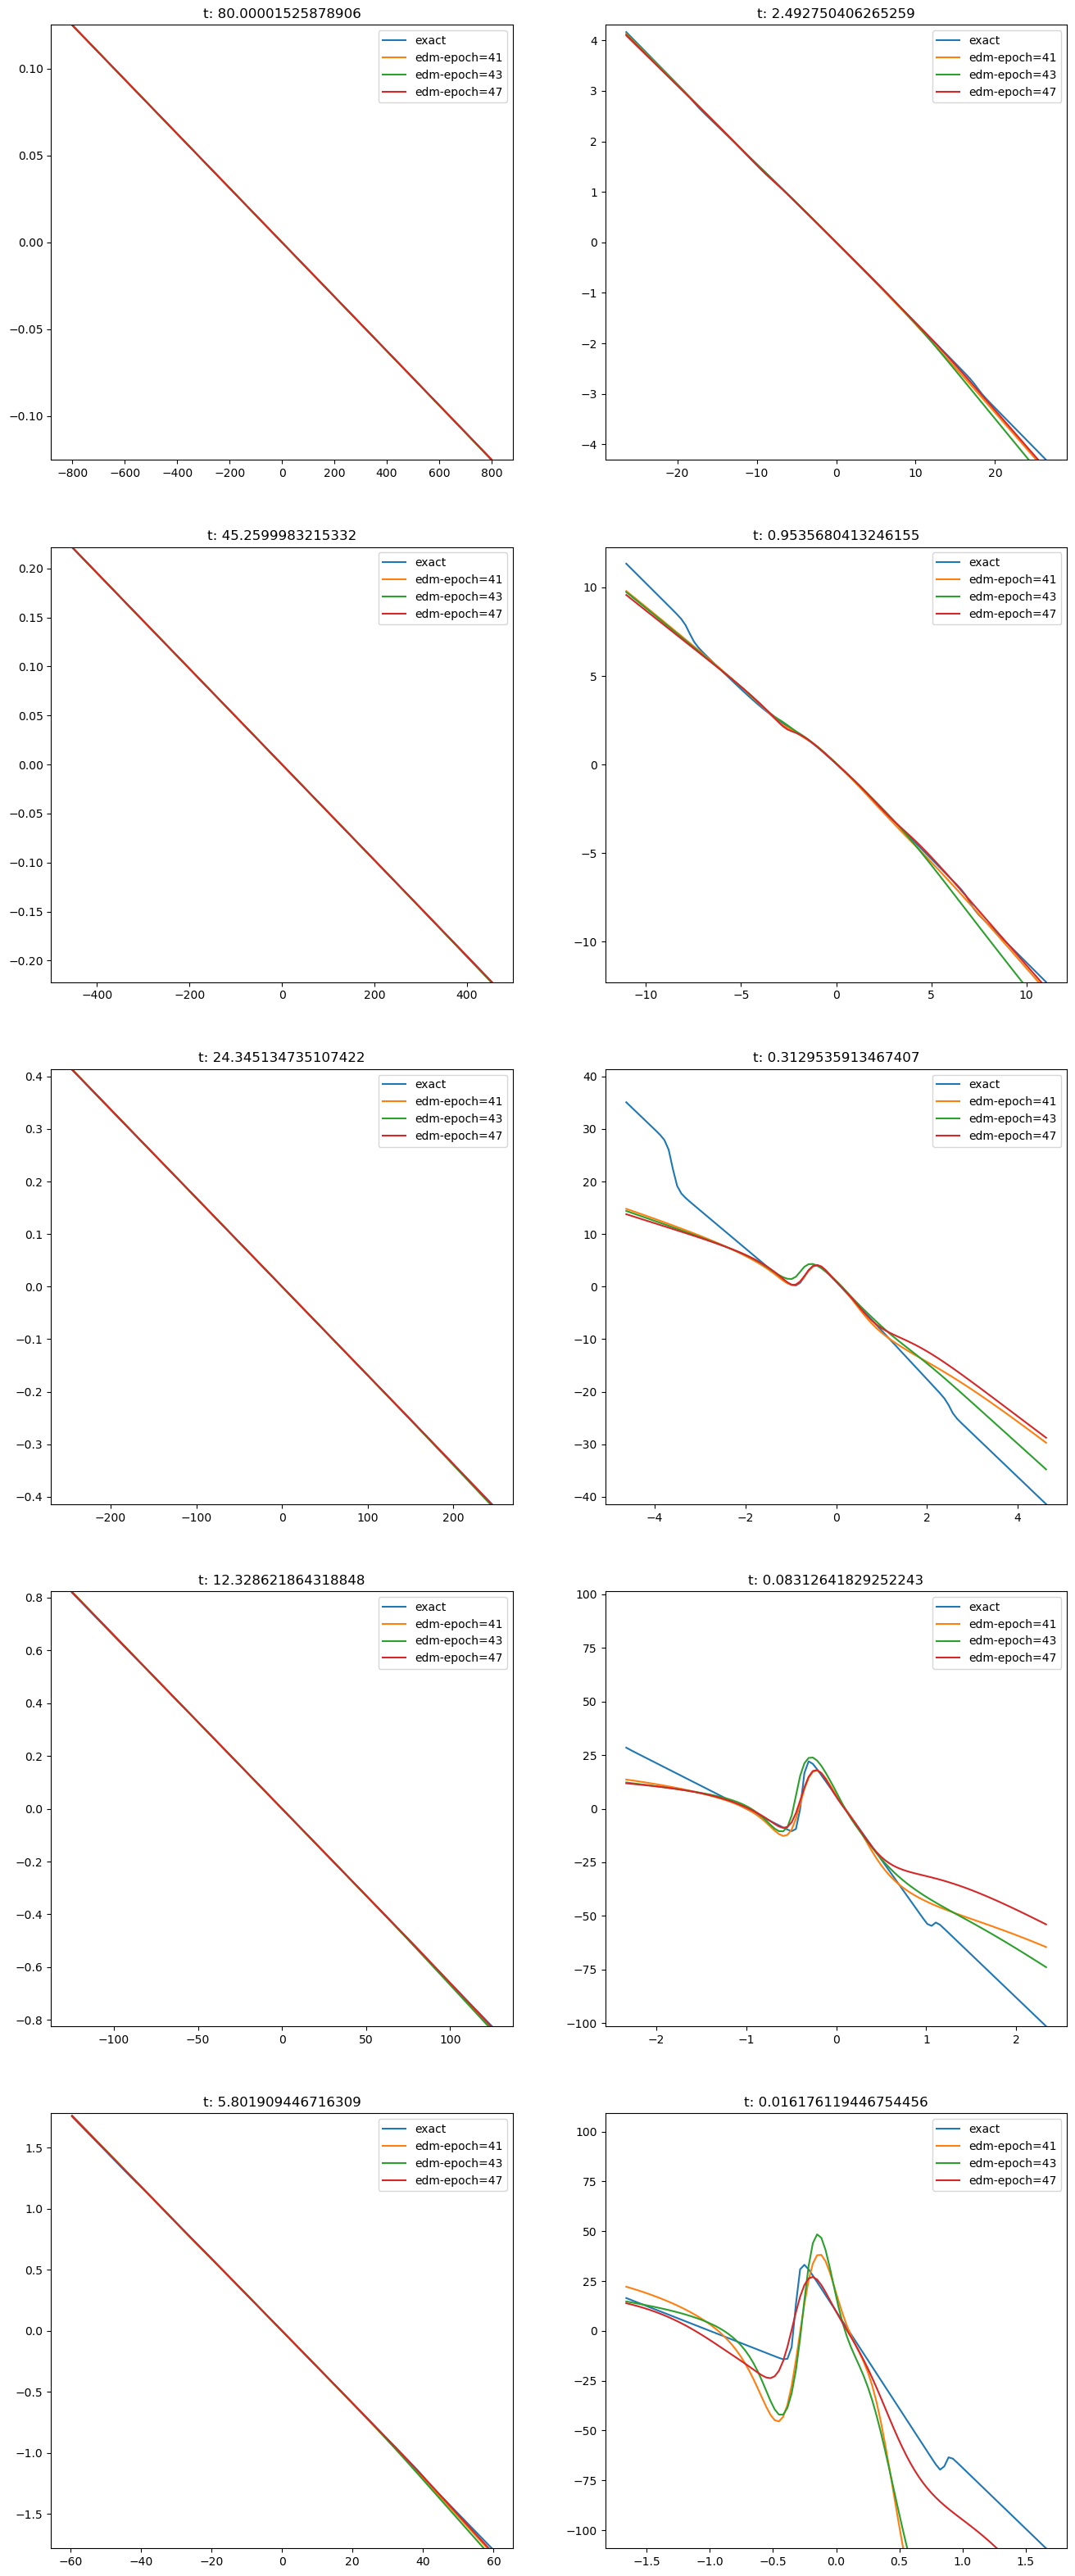

In [37]:
# plot exact and learned score functions in 10 different times
n_t_steps = 10
t_step = len(time)//n_t_steps
fig, axs = plt.subplots(n_t_steps//2, 2, figsize=(16, n_t_steps*4))
for i, t in enumerate(time):
    if i % t_step == 0 and t != 0:
        count = i//t_step
        xlim = 10*scheduler.scheduler_fns.noise_fn(t) + 1.5
        x = torch.linspace(-xlim, xlim, 100).unsqueeze(-1)
        t_tensor = t.unsqueeze(0).repeat(x.shape[0])
        score_exact = analytic_score(x, t_tensor)
        x_, t_ = x.to(device), t_tensor.to(device)
        score1 = score_model1(x_, t_).detach().cpu().numpy()
        score2 = score_model2(x_, t_).detach().cpu().numpy()
        score3 = score_model3(x_, t_).detach().cpu().numpy()
        axs[count%(n_t_steps//2), count//(n_t_steps//2)].plot(x, score_exact, label='exact')
        axs[count%(n_t_steps//2), count//(n_t_steps//2)].plot(x, score1, label='edm-epoch=41')
        axs[count%(n_t_steps//2), count//(n_t_steps//2)].plot(x, score2, label='edm-epoch=43')
        axs[count%(n_t_steps//2), count//(n_t_steps//2)].plot(x, score3, label='edm-epoch=47')

        axs[count%(n_t_steps//2), count//(n_t_steps//2)].legend()
        axs[count%(n_t_steps//2), count//(n_t_steps//2)].set_title(f't: {t}')
        ylim = max(abs(score_exact.max()), abs(score_exact.min()))
        axs[count%(n_t_steps//2), count//(n_t_steps//2)].set_ylim(-ylim, ylim)
plt.show()

<!-- Compute error L^2 norm -->

In [ ]:
# sde_history1 = generate_samples(initial_step, gamma, nsteps, nsamples, dataset, module=module1,
#                                exact_p=exact_p, initial_p=initial_p, sample_type='sde',
#                                checkpoint=checkpointpath1, interval=interval, use_exact_prior=exact_prior,
#                                return_history=True, noisescheduler=scheduler, scheduler_type=process)

# sde_history2 = generate_samples(initial_step, gamma, nsteps, nsamples, dataset, module=module2,
#                                exact_p=exact_p, initial_p=initial_p, sample_type='sde',
#                                checkpoint=checkpointpath2, interval=interval, use_exact_prior=exact_prior,
#                                return_history=True, noisescheduler=scheduler, scheduler_type=process)

# sde_history3 = generate_samples(initial_step, gamma, nsteps, nsamples, dataset, module=module3,
#                                exact_p=exact_p, initial_p=initial_p, sample_type='sde',
#                                checkpoint=checkpointpath3, interval=interval, use_exact_prior=exact_prior,
#                                return_history=True, noisescheduler=scheduler, scheduler_type=process)

In [39]:
# L^2 norm of error
def error_norm(module, step, sde_history, datasize = 2000):
    x = sde_history[step-initial_step, :datasize,].cpu()
    x = x.unsqueeze(-1)
    t = time[step]
    sigma_scalar = scheduler.scheduler_fns.noise_fn(t)
    sigma = sigma_scalar * torch.ones(x.shape[0])
    x_ = x.to(module.device)
    sigma_ = sigma.to(x_)
    s = scheduler.scheduler_fns.scaling_fn(t)
    score = module.get_score(x_/s, sigma_)
    analytic_score = dataset.gradlogprob(x/s, sigma).to(score)
    score_error = torch.mean((score - analytic_score)**2)
    score_error = score_error.detach().cpu().numpy()
    # x_0 = gaussian_samples2[:datasize,].to(module.device)
    x_0 = sde_history[-1, :datasize,].cpu()
    denoiser, _ = module.get_denoiser(x_/s, sigma_)
    denoiser = denoiser.detach().cpu()
    dsm_loss = torch.mean((denoiser - x_0)**2)
    dsm_loss = dsm_loss / sigma_scalar**4
    return score_error, dsm_loss

def compute_error_norm(module, initial_step, sde_history, step_final=nsteps, datasize=2000):
    norm_values = []
    dsm_losses = []
    for step in range(initial_step, step_final):
        score_error, dsm_loss = error_norm(module, step, sde_history, datasize)
        norm_values.append(score_error)
        dsm_losses.append(dsm_loss)
    return norm_values, dsm_losses

def exact_score_norm(initial_step, sde_history, step_final=nsteps, datasize=2000):
    norm_values = []
    for step in range(initial_step, step_final):
        x = sde_history[step-initial_step, :datasize,].cpu()
        x = x.unsqueeze(-1)
        t = time[step]
        sigma_scalar = scheduler.scheduler_fns.noise_fn(t)
        sigma = sigma_scalar * torch.ones(x.shape[0])
        s = scheduler.scheduler_fns.scaling_fn(t)
        analytic_score = dataset.gradlogprob(x/s, sigma)
        norm_value = torch.mean(analytic_score**2)
        norm_values.append(norm_value)
    return norm_values

In [40]:
forward_sde_history = forw_sde_history[:nsteps-initial_step +1].squeeze(-1)
forward_sde_history = forward_sde_history.flip(0)

In [41]:
# compute error
datasize = 10000

error_values1, dsm_losses1 = compute_error_norm(module1, initial_step, forward_sde_history, datasize=datasize)
error_values2, dsm_losses2 = compute_error_norm(module2, initial_step, forward_sde_history, datasize=datasize)
error_values3, dsm_losses3 = compute_error_norm(module3, initial_step, forward_sde_history, datasize=datasize)

# tilde_error_values1, tilde_dsm_losses1 = compute_error_norm(module1, initial_step, sde_history1, datasize=datasize)
# tilde_error_values2, tilde_dsm_losses2 = compute_error_norm(module2, initial_step, sde_history2, datasize=datasize)
# tilde_error_values3, tilde_dsm_losses3 = compute_error_norm(module3, initial_step, sde_history3, datasize=datasize)

all_errors = [error_values1, error_values2, error_values3]

In [42]:
exact_error_values = exact_score_norm(initial_step, forward_sde_history, datasize=datasize)

<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_338593/3469197601.py:18: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('$E_{p_t}[|\epsilon_t|^2]$', fontsize=14)


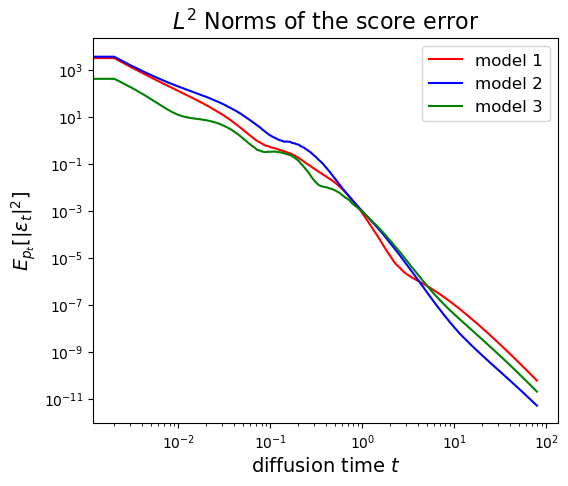

In [43]:
time2 = time[initial_step:]
ntime = len(time2)
times = time2[0] - time2

# plot norm values
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(initial_time - times[1:], error_values1, color='red', label='model 1')
ax.plot(initial_time - times[1:], error_values2, color='blue', label='model 2')
ax.plot(initial_time - times[1:], error_values3, color='green', label='model 3')
# ax.plot(initial_time - times[1:], exact_error_values, color='red', label='exact')

# ax.plot(initial_time - times[1:], tilde_error_values1, color='blue', linestyle='--', alpha = 0.7, label='model 1, $E_\~p$ ($\gamma=1$)')
# ax.plot(initial_time - times[1:], tilde_error_values2, color='orange', linestyle='--', alpha = 0.7, label='model 2, $E_\~p$ ($\gamma=1$)')
# ax.plot(initial_time - times[1:], tilde_error_values3, color='green', linestyle='--', alpha = 0.7, label='model 3, $E_\~p$ ($\gamma=1$)')

ax.set_title('$L^2$ Norms of the score error', fontsize=16)
ax.set_xlabel('diffusion time $t$', fontsize=14)
ax.set_ylabel('$E_{p_t}[|\epsilon_t|^2]$', fontsize=14)
ax.set_yscale('log')
ax.set_xscale('log')
ax.legend(fontsize=12)

## Time-profile correlations

In [17]:
# load all_entropies_saved and all_errors_saved

# Held-out data for threshold selection is read from a precomputed CSV in the first
# multi-threshold figure below, so only path_list is loaded here.
path_list = ['/home/ubuntu/repos/DiffSci/stochasticity_paper/stats/output_default3',
             '/home/ubuntu/repos/DiffSci/stochasticity_paper/stats/output_default4',
             '/home/ubuntu/repos/DiffSci/stochasticity_paper/stats/output_default5']
all_entropies_saved = []
all_errors_saved = []

for path in path_list:
    all_entropies_saved.append(torch.load(f'{path}/all_entropies.pt'))
    all_errors_saved.append(torch.load(f'{path}/all_errors.pt'))

def iter_saved_items(saved_list):
    """Yield (key, value) from each dict in saved_list, preserving keys."""
    for saved_dict in saved_list:
        for key, value in sorted(saved_dict.items()):
            yield key, value

/tmp/ipykernel_2624568/1048049195.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  all_entropies_saved.append(torch.load(f'{path}/all_entropies.pt'))
/tmp/ipykernel_2624

In [18]:
# Parameters for sampling
process = 'edm'

if process == 'edm':
    scheduler = diffsci.models.EDMScheduler()
    initial_time=80
elif process == 'vp':
    scheduler = VPScheduler()
    initial_time=0.205
elif process == 've':
    scheduler = VEScheduler()
    initial_time=0.55
else:
    raise ValueError('Invalid process')

initial_time_ = torch.tensor(initial_time)
nsteps = 500
gamma = 1
nsamples = 100000
tnsamples = 100000
module.config.noisescheduler = scheduler
initial_step = scheduler.step_from_time(initial_time_, nsteps)
time = scheduler.create_steps(nsteps+1)
initial_time = time[initial_step].item()
gamma_max = 20
# interval = [0.02, 0.1]
interval = None

exact_prior = False
print(f'Initial step: {initial_step}')
print(f'Initial_time: {initial_time}')
print(f'Gamma max: {gamma_max}')
print(f'Interval: {interval}')

# generate prior distributions
dataset.num_samples = nsamples
samples = dataset.sample()
sigma = scheduler.scheduler_fns.noise_fn(initial_time_)
scale = scheduler.scheduler_fns.scaling_fn(initial_time_)
initial_p = torch.randn_like(samples) * sigma * scale
exact_p = scheduler.apply_noise(samples, nsteps, initial_step)

exact_prior = False

prior = 'approx_prior'
if exact_prior:
    exact_initial_entropy = 0
    prior = 'exact_prior'

# Generate data for comparison
tmin = time[-2]
print(f'Final time: {tmin}')
sigma_min = scheduler.scheduler_fns.noise_fn(tmin)
scale_min = scheduler.scheduler_fns.scaling_fn(tmin)
noise = torch.randn_like(gaussian_samples2) * sigma_min * scale_min

diffused_gdata2 = scale_min * gaussian_samples2 + noise
diffused_data = diffused_gdata2

Initial step: 0
Initial_time: 80.00001525878906
Gamma max: 20
Interval: None
Final time: 0.0019999996293336153


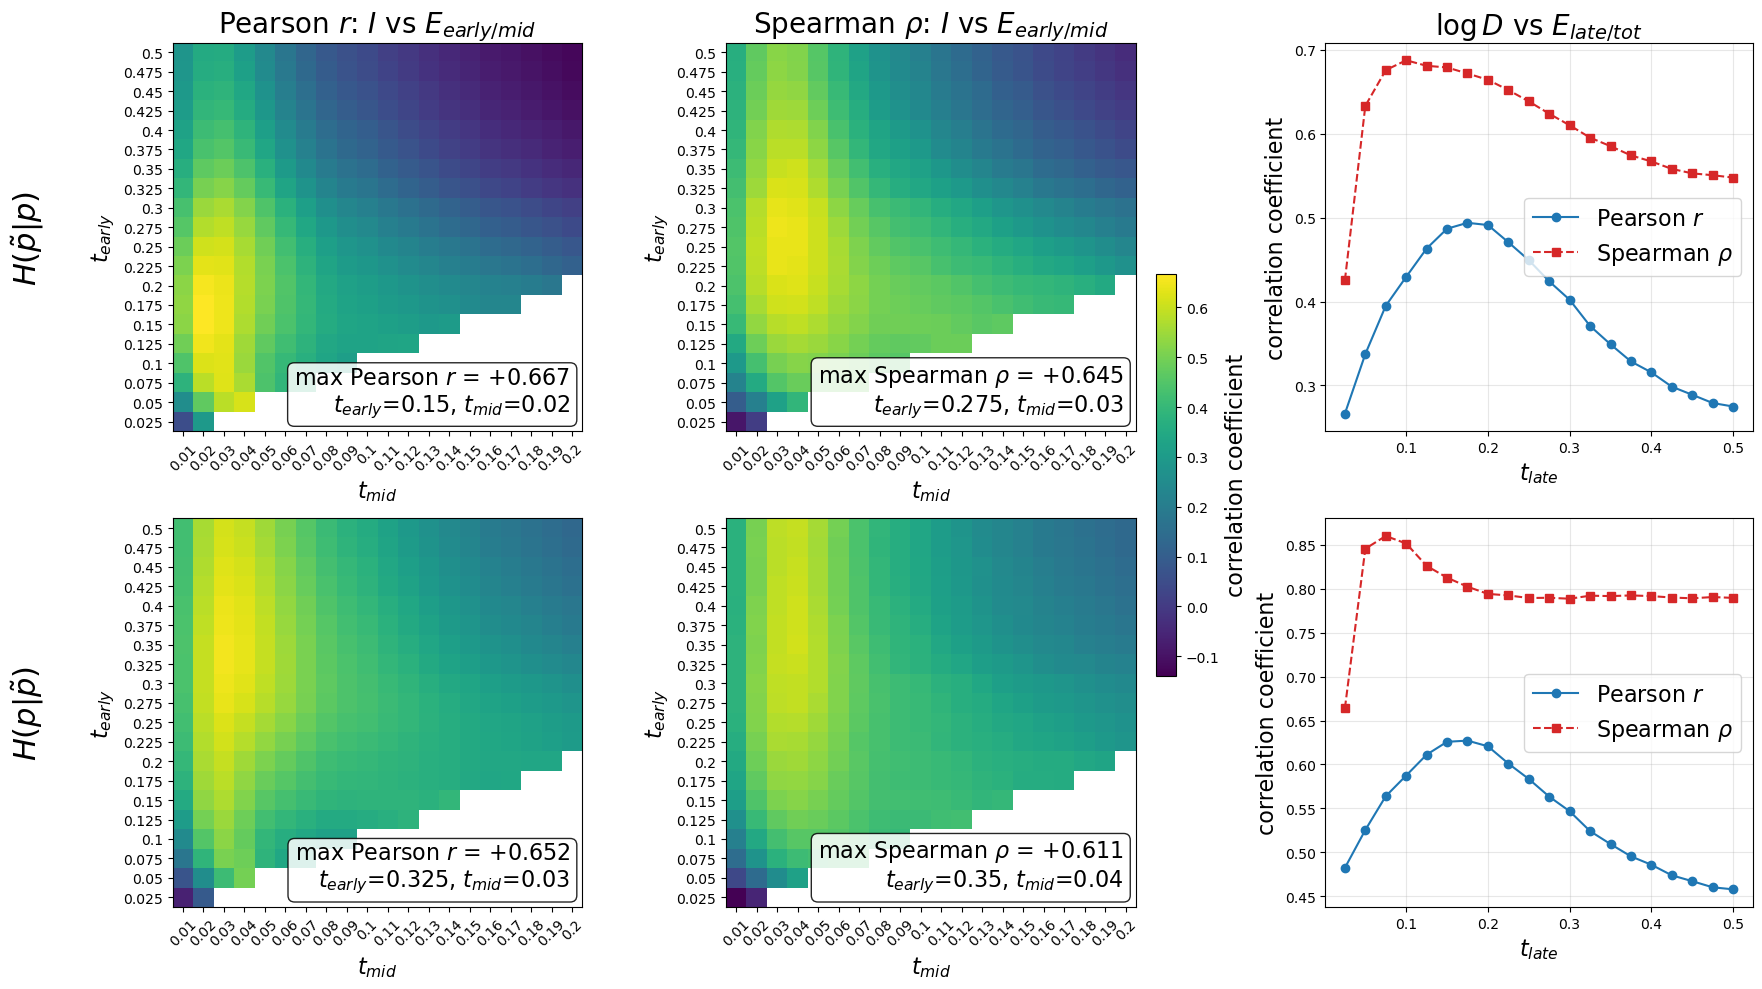

KL 0 best thresholds -> t_early=0.225, t_mid=0.03, t_late=0.15
KL 1 best thresholds -> t_early=0.35, t_mid=0.04, t_late=0.1


In [19]:
# Plots correlations produced by entropy_paper/scripts/test-correlation-thresholds.py
import pandas as pd
from matplotlib import colors as mcolors

# --- chosen parameters --------------------------------------------------
# This figure SELECTS the best thresholds and is built from path_list_heldout.
# Generate this CSV by running the correlation-thresholds script on path_list_heldout:
#   python scripts/test-correlation-thresholds.py --paths ../stats/output_default3/ \
#       --output_file correlations_heldout.csv
csv_path_heldout = '/home/ubuntu/repos/DiffSci/stochasticity_paper/stats/correlation_thresholds_output/correlations_heldout.csv'
# Pass [0] or [1] for a single KL direction (3 plots), or [0, 1] for all 6 plots.
kl_indices = [0, 1]  # 0 -> H(~p|p), 1 -> H(p|~p)
fontsize = 16
# ------------------------------------------------------------------------

kl_labels = {0: r'$H(\~p|p)$', 1: r'$H(p|\~p)$'}


def pivot_grid(data, value):
    # rows: initial_threshold (ascending), cols: final_threshold (ascending)
    grid = data.pivot_table(index='initial_threshold', columns='final_threshold', values=value)
    grid = grid.sort_index(ascending=True)
    grid = grid.reindex(sorted(grid.columns), axis=1)
    return grid


def shared_color_norm(df, kl_indices):
    # shared color scale across all colormap panels
    all_values = []
    for kl_index in kl_indices:
        early = df[(df['type'] == 'early_mid_vs_improvement') & (df['kl_index'] == kl_index)]
        for col in ('pearson_r', 'spearman_r'):
            all_values.append(pivot_grid(early, col).values.ravel())
    all_values = np.concatenate(all_values)
    finite = all_values[np.isfinite(all_values)]
    return mcolors.Normalize(vmin=finite.min(), vmax=finite.max())


def plot_threshold_correlations(df, kl_indices, fontsize=14):
    cmap_norm = shared_color_norm(df, kl_indices)
    nrows = len(kl_indices)
    fig, axs = plt.subplots(nrows, 3, figsize=(20, 5 * nrows), squeeze=False)
    colormap_axes = []

    for row, kl_index in enumerate(kl_indices):
        kl_label = kl_labels[kl_index]
        early = df[(df['type'] == 'early_mid_vs_improvement') & (df['kl_index'] == kl_index)]
        late = df[(df['type'] == 'late_vs_deterioration') & (df['kl_index'] == kl_index)].sort_values('late_threshold')

        heatmaps = [
            (axs[row][0], 'pearson_r', r'Pearson $r$'),
            (axs[row][1], 'spearman_r', r'Spearman $\rho$'),
        ]
        for ax, col, name in heatmaps:
            grid = pivot_grid(early, col)
            ax.imshow(
                grid.values, origin='lower', aspect='auto',
                cmap='viridis', norm=cmap_norm,
            )
            colormap_axes.append(ax)
            ax.set_xticks(range(len(grid.columns)))
            ax.set_xticklabels([f'{c:.3g}' for c in grid.columns], rotation=45)
            ax.set_yticks(range(len(grid.index)))
            ax.set_yticklabels([f'{r:.3g}' for r in grid.index])
            ax.set_xlabel('$t_{mid}$', fontsize=fontsize)
            ax.set_ylabel('$t_{early}$', fontsize=fontsize)
            if row == 0:
                ax.set_title(f'{name}: $I$ vs $E_{{early/mid}}$', fontsize=fontsize+4)

            # optimal pair of thresholds (largest coefficient)
            best = early.loc[early[col].idxmax()]
            ax.text(
                0.97, 0.03,
                f'max {name} = {best[col]:+.3f}\n'
                f'$t_{{early}}$={best["initial_threshold"]:.3g}, '
                f'$t_{{mid}}$={best["final_threshold"]:.3g}',
                transform=ax.transAxes, fontsize=fontsize, va='bottom', ha='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
            )

        ax = axs[row][2]
        ax.plot(late['late_threshold'], late['pearson_r'], 'o-', color='tab:blue', label=r'Pearson $r$')
        ax.plot(late['late_threshold'], late['spearman_r'], 's--', color='tab:red', label=r'Spearman $\rho$')
        ax.set_xlabel('$t_{late}$', fontsize=fontsize)
        ax.set_ylabel('correlation coefficient', fontsize=fontsize)
        if row == 0:
            ax.set_title(r'$\log D$ vs $E_{late/tot}$', fontsize=fontsize+4)
        ax.legend(fontsize=fontsize)
        ax.grid(alpha=0.3)

        # KL divergence type indicator on the far left of the row
        axs[row][0].annotate(
            kl_label, xy=(0, 0.5), xycoords='axes fraction',
            xytext=(-fontsize * 6.5, 0), textcoords='offset points',
            rotation=90, va='center', ha='center', fontsize=fontsize + 6,
            fontweight='bold',
        )

    fig.tight_layout()
    fig.subplots_adjust(left=0.13, right=0.92, wspace=0.35)
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=cmap_norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=colormap_axes, fraction=0.02, pad=0.02)
    cbar.set_label('correlation coefficient', fontsize=fontsize)
    return fig


def best_thresholds(df, kl_indices, corr_index='pearson_r'):
    initials, finals, lates = [], [], []
    for kl_index in kl_indices:
        early = df[(df['type'] == 'early_mid_vs_improvement') & (df['kl_index'] == kl_index)]
        late = df[(df['type'] == 'late_vs_deterioration') & (df['kl_index'] == kl_index)]
        if corr_index == 'both':
            # take the best of the sum of the two
            early_best = early.loc[(early['pearson_r'] + early['spearman_r']).idxmax()]
            late_best = late.loc[(late['pearson_r'] + late['spearman_r']).idxmax()]
        else:
            early_best = early.loc[early[corr_index].idxmax()]
            late_best = late.loc[late[corr_index].idxmax()]
        initials.append(early_best['initial_threshold'])
        finals.append(early_best['final_threshold'])
        lates.append(late_best['late_threshold'])
    return initials, finals, lates


df = pd.read_csv(csv_path_heldout)
plot_threshold_correlations(df, kl_indices, fontsize=fontsize)
plt.show()

# per-KL best thresholds reused by the next cell to build the error-window metrics
corr_index = 'both'
best_initial_thresholds, best_final_thresholds, best_late_thresholds = best_thresholds(df, kl_indices, corr_index)
for kl_index, t_early, t_mid, t_late in zip(
    kl_indices, best_initial_thresholds, best_final_thresholds, best_late_thresholds,
):
    print(
        f'KL {kl_index} best thresholds -> '
        f't_early={t_early:.3g}, t_mid={t_mid:.3g}, t_late={t_late:.3g}'
    )

In [21]:
# scalar metrics for g_entropies and for the error values

# per-KL error-window thresholds taken from the best correlation thresholds (previous cell)
initial_thresholds = best_initial_thresholds
final_thresholds = best_final_thresholds
late_thresholds = best_late_thresholds
# ------------------------------------------------------------------------


def compute_entropy_metrics(all_entropies_saved):
    # all_entropies_saved: list[dict[epoch -> (gamma_values, sde_entropies, inv_sde_entropies)]]
    improvements, deteriorations, epochs = [], [], []
    for epoch, g_ent in iter_saved_items(all_entropies_saved):
        gamma_values, sde_entropies, inv_sde_entropies = g_ent
        improvement, deterioration = [], []
        for ent in [sde_entropies, inv_sde_entropies]:
            improvement.append((ent[0] - min(ent)) / min(ent))
            deterioration.append((ent[-1] - min(ent)) / min(ent))
        improvements.append(improvement)
        deteriorations.append(deterioration)
        epochs.append(epoch)
    improvements = np.array(improvements)
    deteriorations = np.log(np.array(deteriorations))
    return epochs, improvements, deteriorations


def compute_error_ratios(all_errors_saved, initial_thresholds, final_thresholds, late_thresholds):
    # per-KL thresholds -> per-KL error ratios; arrays shaped (n_epochs, n_kl)
    # all_errors_saved: list[dict[epoch -> (error_values, dsm_losses)]]
    steps_initial = [int(scheduler.step_from_time(t=t, n=nsteps)) for t in initial_thresholds]
    steps_final = [int(scheduler.step_from_time(t=t, n=nsteps)) for t in final_thresholds]
    steps_late = [int(scheduler.step_from_time(t=t, n=nsteps)) for t in late_thresholds]

    early_error_ratios, early_mid_error_ratios, late_error_ratios = [], [], []
    for epoch, (error_values, dsm_losses) in iter_saved_items(all_errors_saved):
        error_values = np.array(error_values)
        total_error = np.sum(error_values)
        early_row, early_mid_row, late_row = [], [], []
        for step_initial, step_final, step_late in zip(steps_initial, steps_final, steps_late):
            early_error = np.sum(error_values[:step_initial])
            middle_error = np.sum(error_values[step_initial:step_final])
            late_error = np.sum(error_values[step_late:])
            early_row.append(early_error / total_error)
            early_mid_row.append(early_error / middle_error)
            late_row.append(late_error / total_error)
        early_error_ratios.append(early_row)
        early_mid_error_ratios.append(early_mid_row)
        late_error_ratios.append(late_row)
    return (
        np.array(early_error_ratios),
        np.array(early_mid_error_ratios),
        np.array(late_error_ratios),
    )


epochs, improvements, deteriorations = compute_entropy_metrics(all_entropies_saved)
early_error_ratios, early_mid_error_ratios, late_error_ratios = compute_error_ratios(
    all_errors_saved, initial_thresholds, final_thresholds, late_thresholds,
)

<>:143: SyntaxWarning: invalid escape sequence '\l'
<>:143: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2624568/1524797198.py:143: SyntaxWarning: invalid escape sequence '\l'
  r'Deterioration $\times$ late/total error', '$E_{late/tot}$', '$\log D$'),


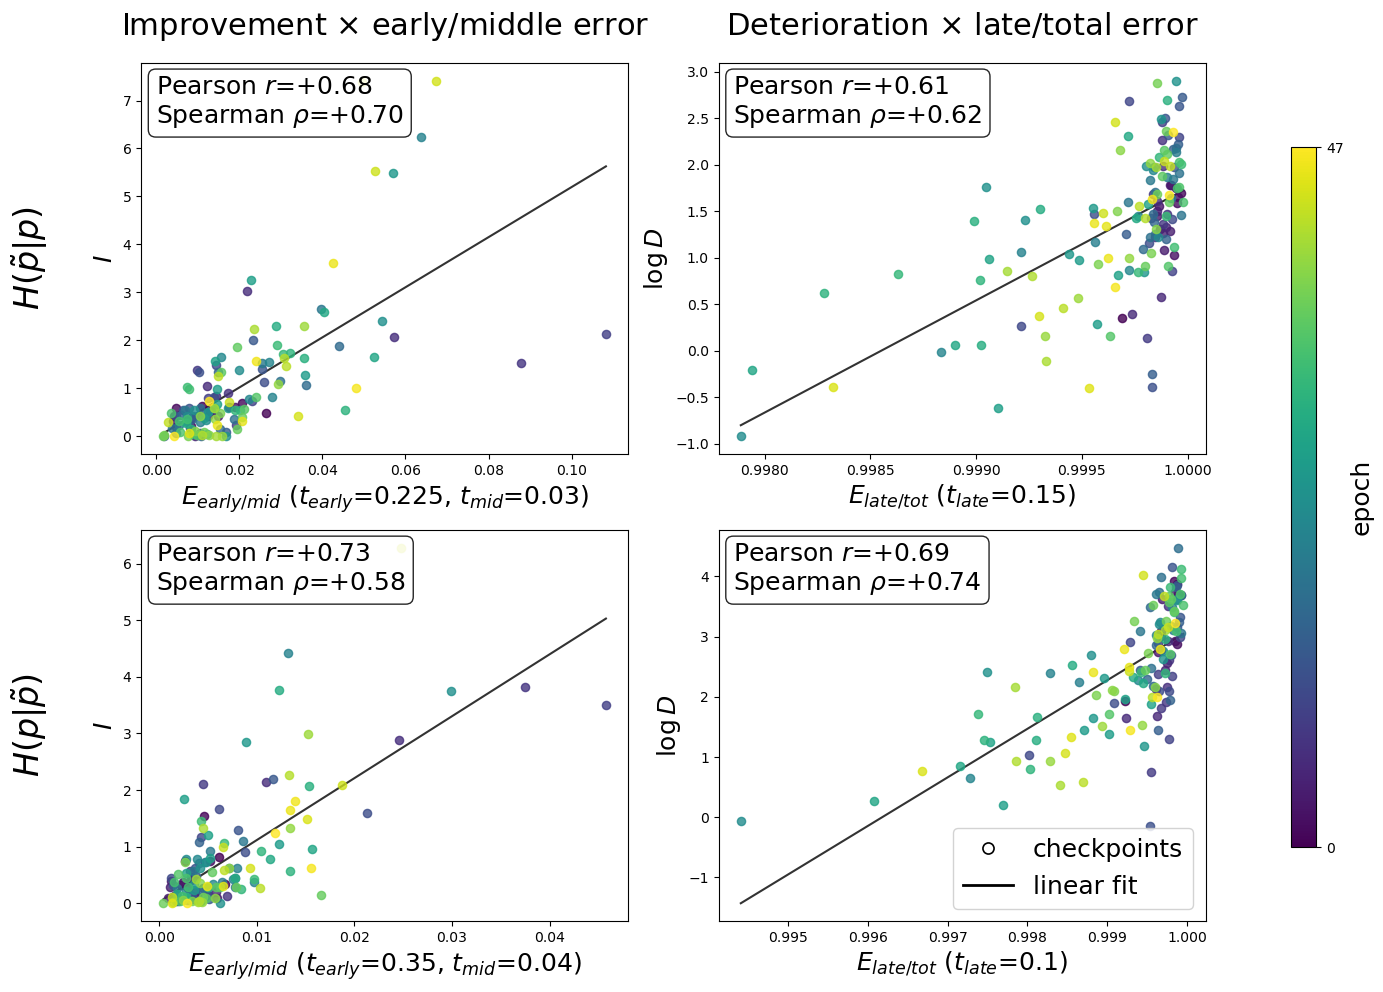

In [22]:
# scatter plots with correlation statistics and linear fits
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors
from scipy.stats import pearsonr, spearmanr, linregress

# --- chosen parameters --------------------------------------------------
include_p_values = False
font_size = 18
epoch_threshold = -1
axis_pad = 0.05
stats_text_xy = (0.03, 0.97)
colorbar_bbox = [1.05, 0.15, 0.02, 0.7]
kl_offset = -80
kl_names = [r'$H(\~p|p)$', r'$H(p|\~p)$']
# ------------------------------------------------------------------------


def format_stats_text(x, y, include_p_values):
    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)
    if include_p_values:
        return (
            r'Pearson $r$' + f'={pearson_r:+.2f}' + f' (p={pearson_p:.2e}),'
            + r'Spearman $\rho$' + f'={spearman_r:+.2f}' + f' (p={spearman_p:.2e})'
        )
    return (
        r'Pearson $r$' + f'={pearson_r:+.2f}\n'
        + r'Spearman $\rho$' + f'={spearman_r:+.2f}'
    )


def plot_correlation_scatter(
    panels, kl_names, epochs,
    initial_thresholds, final_thresholds, late_thresholds,
):
    epochs_array = np.asarray(epochs)
    epoch_norm = mcolors.Normalize(vmin=epochs_array.min(), vmax=epochs_array.max())
    cmap = plt.cm.viridis
    colors = cmap(np.linspace(0, 1, len(epochs_array)))

    n_kl, n_panels = len(kl_names), len(panels)
    fig, axs = plt.subplots(n_kl, n_panels, figsize=(n_panels * 5 + 2.5, n_kl * 5))
    axs = np.atleast_2d(axs)

    data_handles = [
        Line2D(
            [0], [0], marker='o', markerfacecolor='none', markeredgecolor='k',
            markeredgewidth=1.2, linestyle='None', markersize=8, label='checkpoints',
        ),
        Line2D([0], [0], color='k', linewidth=2, linestyle='-', label='linear fit'),
    ]

    for col, (x_all, y_all, title, xlabel, ylabel) in enumerate(panels):
        for j, kl_name in enumerate(kl_names):
            ax = axs[j, col]
            x = np.asarray(x_all, dtype=float)[:, j]
            y = np.asarray(y_all[:, j], dtype=float)
            for i in range(len(x)):
                ax.scatter(
                    x[i], y[i], color=colors[i], marker='o',
                    s=35, zorder=3, alpha=0.8,
                )

            fit = linregress(x, y)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(
                x_line, fit.slope * x_line + fit.intercept,
                color='k', linestyle='-', alpha=0.8, zorder=2,
            )

            if j == 0:
                ax.set_title(title, fontsize=font_size + 4, y=1.05)
            ax.set_ylabel(ylabel, fontsize=font_size)
            if col == 0:
                xlab = (
                    rf'$E_{{early/mid}}$ '
                    rf'($t_{{early}}$={initial_thresholds[j]:.3g}, '
                    rf'$t_{{mid}}$={final_thresholds[j]:.3g})'
                )
            else:
                xlab = rf'$E_{{late/tot}}$ ($t_{{late}}$={late_thresholds[j]:.3g})'
            ax.set_xlabel(xlab, fontsize=font_size)
            ax.text(
                stats_text_xy[0], stats_text_xy[1],
                format_stats_text(x, y, include_p_values),
                transform=ax.transAxes, fontsize=font_size, va='top', ha='left',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
            )

    for col, (x_all, y_all, *_rest) in enumerate(panels):
        for j in range(n_kl):
            ax = axs[j, col]
            x = np.asarray(x_all, dtype=float)[:, j]
            y = np.asarray(y_all[:, j], dtype=float)
            fit = linregress(x, y)
            x_line = np.linspace(x.min(), x.max(), 100)
            x_vals = list(x) + list(x_line)
            y_vals = list(y) + list(fit.slope * x_line + fit.intercept)
            x_lo, x_hi = min(x_vals), max(x_vals)
            y_lo, y_hi = min(y_vals), max(y_vals)
            x_margin = axis_pad * (x_hi - x_lo) if x_hi > x_lo else axis_pad
            y_margin = axis_pad * (y_hi - y_lo) if y_hi > y_lo else axis_pad
            ax.set_xlim(x_lo - x_margin, x_hi + x_margin)
            ax.set_ylim(y_lo - y_margin, y_hi + y_margin)

    for j, kl_name in enumerate(kl_names):
        axs[j, 0].annotate(
            kl_name, xy=(0, 0.5), xycoords='axes fraction',
            xytext=(kl_offset, 0), textcoords='offset points',
            rotation=90, va='center', ha='center', fontsize=font_size + 6,
            fontweight='bold',
        )

    fig.tight_layout()
    fig.subplots_adjust(left=0.13)

    axs[-1, -1].legend(
        handles=data_handles, loc='lower right', fontsize=font_size,
        framealpha=0.85, fancybox=True,
    )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=epoch_norm)
    sm.set_array([])
    cax = fig.add_axes(colorbar_bbox)
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_ticks([epochs_array.min(), epochs_array.max()])
    cbar.set_ticklabels([str(epochs_array.min()), str(epochs_array.max())])
    cbar.set_label('epoch', fontsize=font_size)


# filter checkpoints by epoch index
mask = np.arange(len(epochs)) > epoch_threshold
early_mid_error_ratios_f = np.asarray(early_mid_error_ratios)[mask]
late_error_ratios_f = np.asarray(late_error_ratios)[mask]
improvements_f = np.asarray(improvements)[mask]
deteriorations_f = np.asarray(deteriorations)[mask]
epochs_f = [epoch for i, epoch in enumerate(epochs) if i > epoch_threshold]

panels = [
    (early_mid_error_ratios_f, improvements_f,
     r'Improvement $\times$ early/middle error', '$E_{early/mid}$', '$I$'),
    (late_error_ratios_f, deteriorations_f,
     r'Deterioration $\times$ late/total error', '$E_{late/tot}$', '$\log D$'),
]

plot_correlation_scatter(
    panels, kl_names, epochs_f,
    initial_thresholds, final_thresholds, late_thresholds,
)

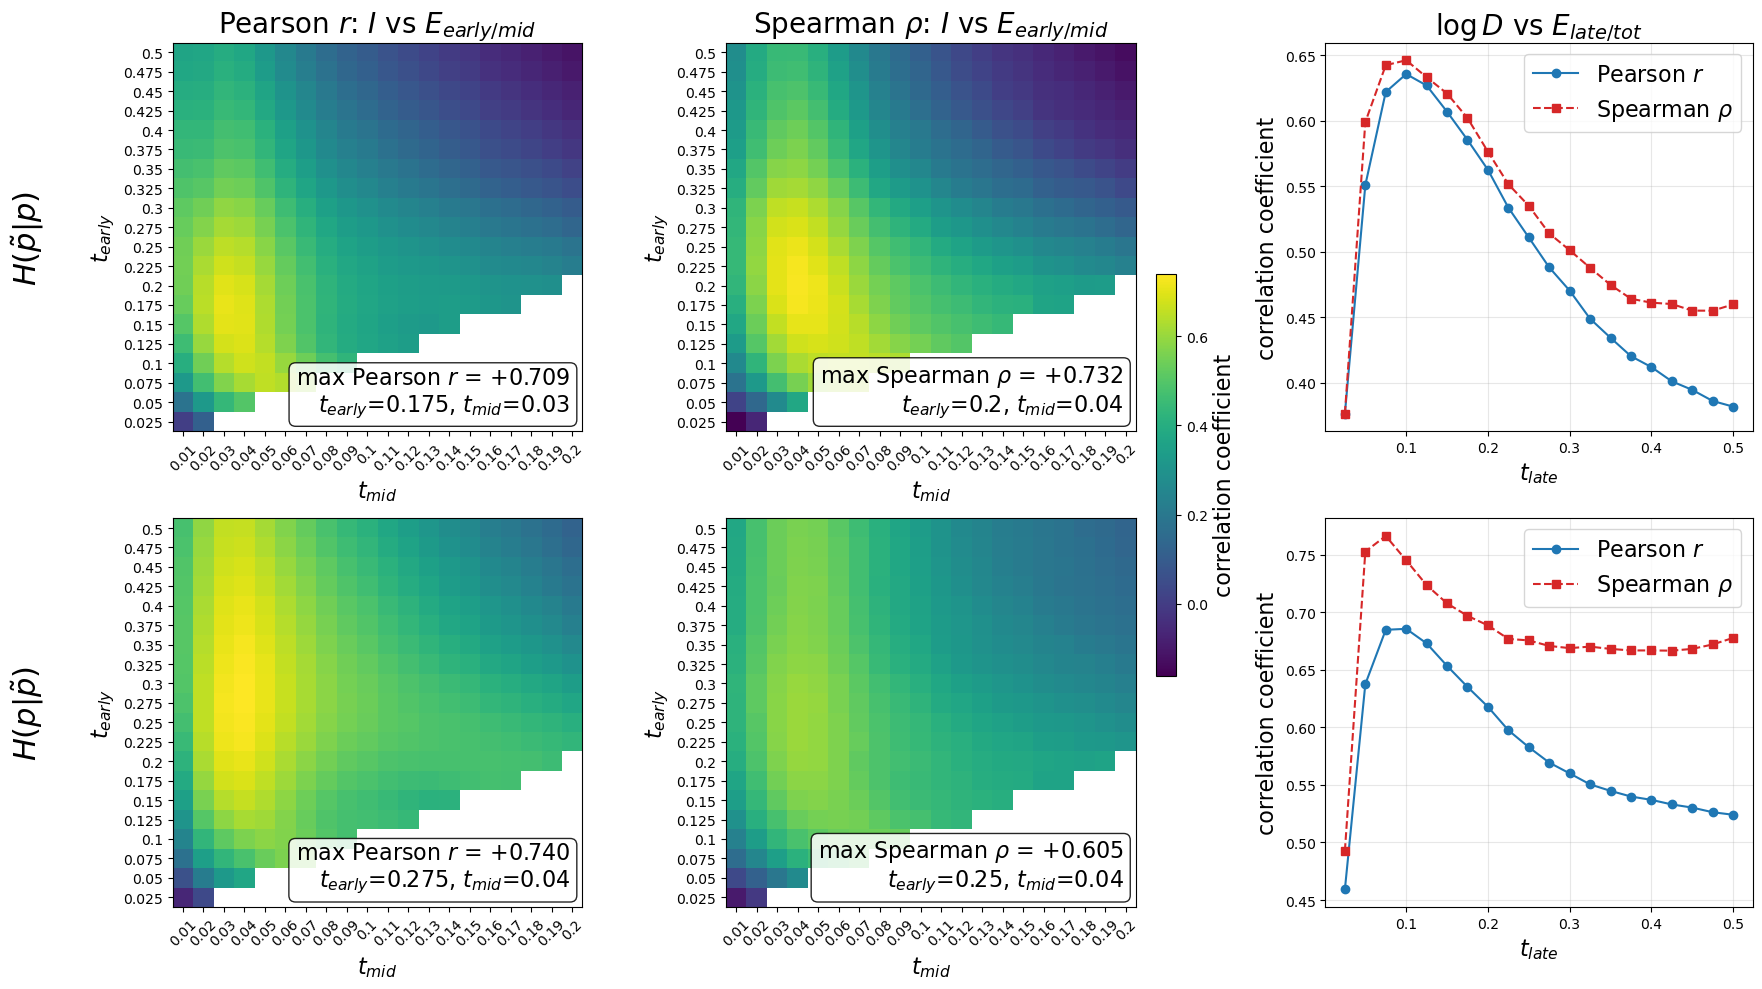

In [24]:
# Multi-threshold correlation figure for path_list (same layout as the first figure).
# Generate this CSV by running the correlation-thresholds script on path_list:
#   python scripts/test-correlation-thresholds.py \
#       --paths ../stats/output_default4/ ../stats/output_default5/ \
#       --output_file correlations_main.csv
csv_path_main = '/home/ubuntu/repos/DiffSci/stochasticity_paper/stats/correlation_thresholds_output/correlations.csv'

df_main = pd.read_csv(csv_path_main)
plot_threshold_correlations(df_main, kl_indices, fontsize=fontsize)
plt.show()

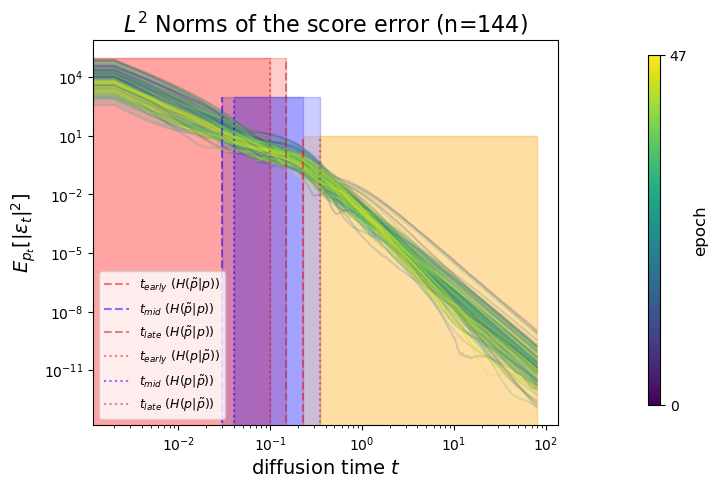

In [25]:
# plot all_errors_saved (error norms for path_list)
from matplotlib import colors as mcolors

time2 = time[initial_step:]
times = time2[0] - time2
x = initial_time - times[1:]

# epoch colour scale (recreated here; defined inside the scatter function above)
epochs_f_array = np.asarray(epochs_f)
cmap = plt.cm.viridis
epoch_norm = mcolors.Normalize(vmin=epochs_f_array.min(), vmax=epochs_f_array.max())

n_error_items = sum(len(d) for d in all_errors_saved)
colors = cmap(np.linspace(0, 1, n_error_items))
alpha = 0.2
alpha_lines = 0.5
alpha_fill = 0.2

fig, ax = plt.subplots(figsize=(6, 5))
for i, (epoch, (error_values, dsm_losses)) in enumerate(iter_saved_items(all_errors_saved)):
    ax.plot(x, np.asarray(error_values), color=colors[i], alpha=alpha)

# per-KL threshold regions used for the error-window metrics (one line style per KL)
ylim = ax.get_ylim()
kl_linestyles = ['--', ':', '-.']
for k in range(len(initial_thresholds)):
    kl_label = kl_names[k] if k < len(kl_names) else f'KL {k}'
    ls = kl_linestyles[k % len(kl_linestyles)]
    ax.vlines(initial_thresholds[k], 0, 10, color='red', linestyle=ls, alpha=alpha_lines,
              label=fr'$t_{{early}}$ ({kl_label})')
    ax.vlines(final_thresholds[k], 0, 1000, color='blue', linestyle=ls, alpha=alpha_lines,
              label=fr'$t_{{mid}}$ ({kl_label})')
    ax.vlines(late_thresholds[k], 0, 100000, color='brown', linestyle=ls, alpha=alpha_lines,
              label=fr'$t_{{late}}$ ({kl_label})')
    ax.fill_betweenx(ylim, 0, late_thresholds[k], color='red', alpha=alpha_fill)
    ax.fill_betweenx((0, 1000), initial_thresholds[k], final_thresholds[k], color='blue', alpha=alpha_fill)
    ax.fill_betweenx((0, 10), initial_thresholds[k], 80, color='orange', alpha=alpha_fill)

ax.set_title(f'$L^2$ Norms of the score error (n={len(early_mid_error_ratios_f)})', fontsize=16)
ax.set_xlabel('diffusion time $t$', fontsize=14)
ax.set_ylabel(r'$E_{p_t}[|\epsilon_t|^2]$', fontsize=14)
ax.set_yscale('log')
ax.set_xscale('log')
ax.legend(fontsize=9)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=epoch_norm)
sm.set_array([])
cax = fig.add_axes(colorbar_bbox)
cbar = fig.colorbar(sm, cax=cax)
cbar.set_ticks([epochs_f_array.min(), epochs_f_array.max()])
cbar.set_ticklabels([str(epochs_f_array.min()), str(epochs_f_array.max())])
cbar.set_label('epoch', fontsize=12)

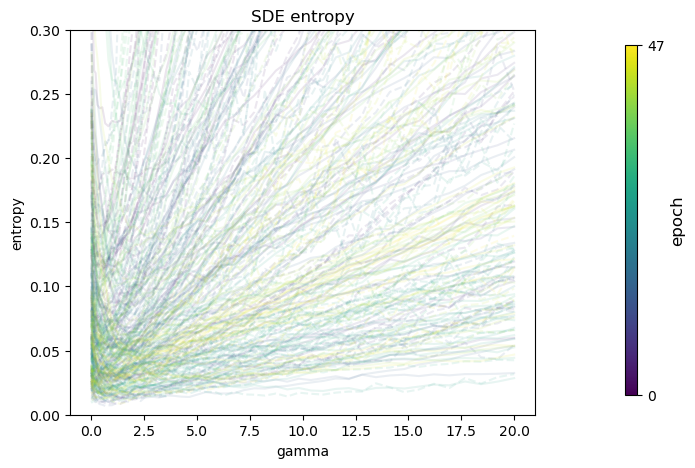

In [26]:
# plot all_entropies (entropy curves for path_list)
from matplotlib import colors as mcolors

# epoch colour scale (recreated here; defined inside the scatter function above)
epochs_f_array = np.asarray(epochs_f)
cmap = plt.cm.viridis
epoch_norm = mcolors.Normalize(vmin=epochs_f_array.min(), vmax=epochs_f_array.max())

n_entropy_items = sum(len(d) for d in all_entropies_saved)
colors = cmap(np.linspace(0, 1, n_entropy_items))

fig, ax = plt.subplots(figsize=(6, 5))
alpha = 0.1
for i, (epoch, g_ent) in enumerate(iter_saved_items(all_entropies_saved)):
    gamma_values, sde_entropies, inv_sde_entropies = g_ent
    if i > epoch_threshold:
        ax.plot(gamma_values, sde_entropies, label=f'model {epoch}', color=colors[i], alpha=alpha)
        ax.plot(gamma_values, inv_sde_entropies, linestyle='--', color=colors[i], alpha=alpha)
ax.set_title('SDE entropy')
ax.set_xlabel('gamma')
ax.set_ylabel('entropy')
ax.set_ylim(0, 0.3)
# ax.set_xlim(0, 1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=epoch_norm)
sm.set_array([])
cax = fig.add_axes(colorbar_bbox)
cbar = fig.colorbar(sm, cax=cax)
cbar.set_ticks([epochs_f_array.min(), epochs_f_array.max()])
cbar.set_ticklabels([str(epochs_f_array.min()), str(epochs_f_array.max())])
cbar.set_label('epoch', fontsize=12)


<!-- MANIPULATING THE ERROR SPECTRA -->

## KL evolution

NoiseScheduler: EDMScheduler(
  (scheduler_fns): EDMSchedulingFunctions()
  (_integrator): EulerIntegrator()
  (stochastic_integrator): EulerMaruyamaIntegrator()
  (_temporary_integrator): None
)
Exact initial entropy = 0.00000


/tmp/ipykernel_338593/70221041.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s = torch.tensor(sigma*scale)


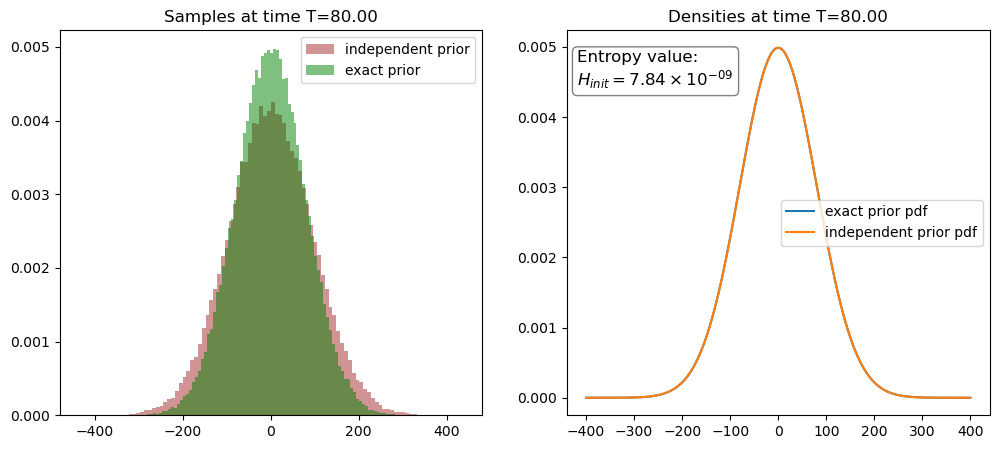

Sampling with learned scores, device:  cuda:0


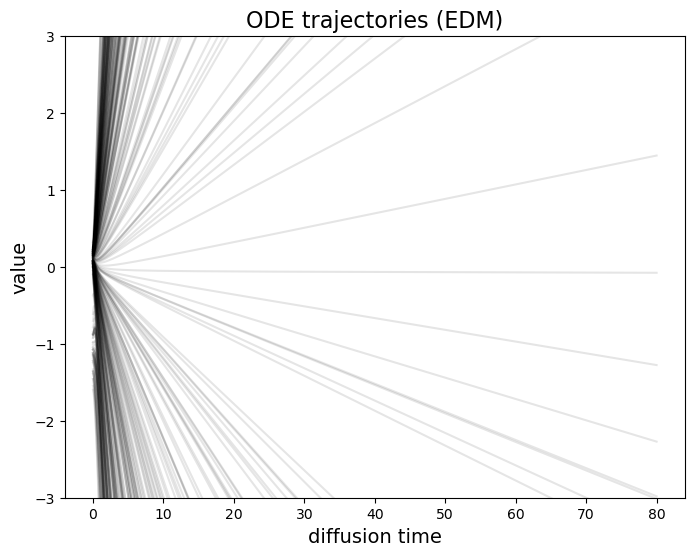

Saving samples to /home/ubuntu/repos/DiffSci/savedmodels/experimental/mixt_gauss2_silu-width=128-bs=16-precond=edm-diffsci-train=4000-nlm=default/saved_samples/ode-indep_prior-tr-nsamples=1e+05-nsteps=500-T=80.000-his-EDM
NoiseScheduler: EDMScheduler(
  (scheduler_fns): EDMSchedulingFunctions()
  (_integrator): EulerIntegrator()
  (stochastic_integrator): EulerMaruyamaIntegrator()
  (_temporary_integrator): None
)
Exact initial entropy = 0.00000


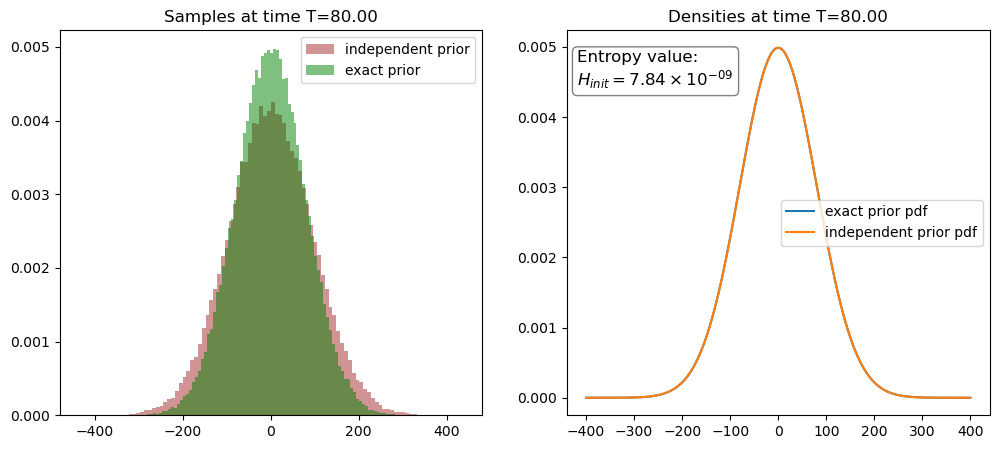

Sampling with learned scores, device:  cuda:0


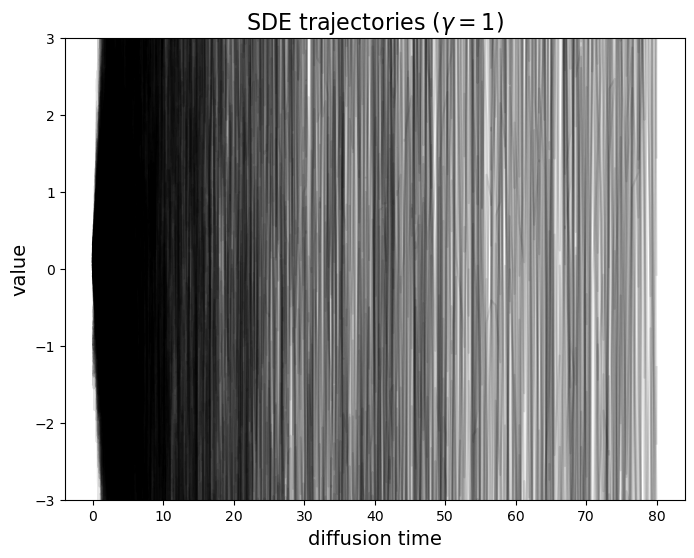

Saving samples to /home/ubuntu/repos/DiffSci/savedmodels/experimental/mixt_gauss2_silu-width=128-bs=16-precond=edm-diffsci-train=4000-nlm=default/saved_samples/sde-indep_prior-tr-nsamples=1e+05-nsteps=500-T=80.000-g=1-his-EDM


In [66]:
checkpointpath1 = r"/home/ubuntu/repos/DiffSci/savedmodels/experimental/mixt_gauss2_silu-width=128-bs=16-precond=edm-diffsci-train=4000-nlm=default/checkpoints/sample-epoch=41-valid_loss=0.254058.ckpt"
module1 = KarrasModule.load_from_checkpoint(model=model, config=config, checkpoint_path=checkpointpath1)

checkpointpath2 = r"/home/ubuntu/repos/DiffSci/savedmodels/experimental/mixt_gauss2_silu-width=128-bs=16-precond=edm-diffsci-train=4000-nlm=default2/checkpoints/sample-epoch=47-valid_loss=0.249473.ckpt"
module2 = KarrasModule.load_from_checkpoint(model=model, config=config, checkpoint_path=checkpointpath2)

checkpointpath3 = r"/home/ubuntu/repos/DiffSci/savedmodels/production/mixt_gauss2_silu-width=128-bs=16-precond=edm-default-train=4000-nonres2/checkpoints/sample-epoch=43-valid_loss=0.290424.ckpt"
module3 = KarrasModule.load_from_checkpoint(model=model, config=config, checkpoint_path=checkpointpath3)


module = module1
checkpointpath = checkpointpath1

case = 'perturbed prior'

if case == 'perturbed prior':
    gamma = 1
    prior_factor = 1.2
elif case == 'different KLs':
    gamma = 6
    prior_factor = 1
else:
    raise ValueError(f'Invalid case: {case}')


perturbed_p = initial_p * prior_factor
exact_prior = False

ode_history = generate_samples(initial_step, gamma, nsteps, nsamples, dataset, module=module,
                               exact_p=exact_p, initial_p=perturbed_p, sample_type='ode',
                               checkpoint=checkpointpath, interval=interval, use_exact_prior=exact_prior,
                               return_history=True, noisescheduler=scheduler, scheduler_type=process)

sde_history = generate_samples(initial_step, gamma, nsteps, nsamples, dataset, module=module,
                               exact_p=exact_p, initial_p=perturbed_p, sample_type='sde',
                               checkpoint=checkpointpath, interval=interval, use_exact_prior=exact_prior,
                               return_history=True, noisescheduler=scheduler, scheduler_type=process)

/tmp/ipykernel_338593/70221041.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s = torch.tensor(sigma*scale)


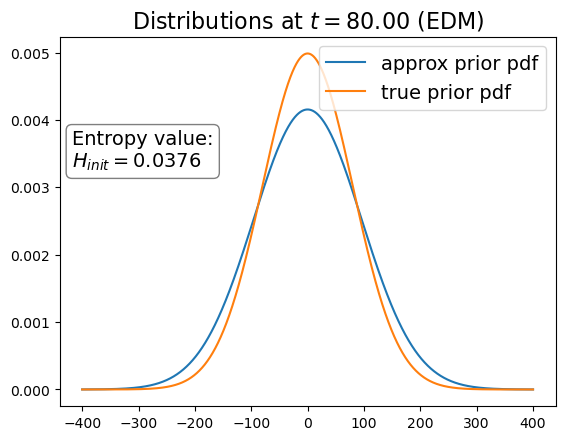

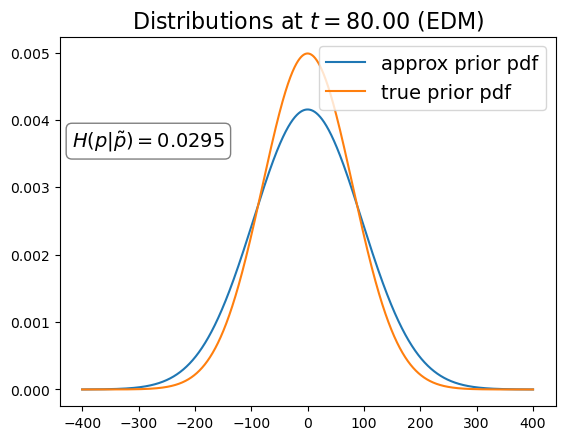

In [67]:
ode_samples = ode_history[-1]
sde_samples = sde_history[-1]

sigma = scheduler.scheduler_fns.noise_fn(initial_time_)
xlim = 5*sigma
exact_initial_entropy = analytical_initial_entropy(dataset, initial_time, scheduler=scheduler, plot=True, xlim=xlim,
                                                   process=process, prior_factor=prior_factor)
inv_initial_entropy = analytical_initial_entropy(dataset, initial_time, scheduler=scheduler, plot=True, xlim=xlim,
                                                process=process, inverseH=True, prior_factor=prior_factor)

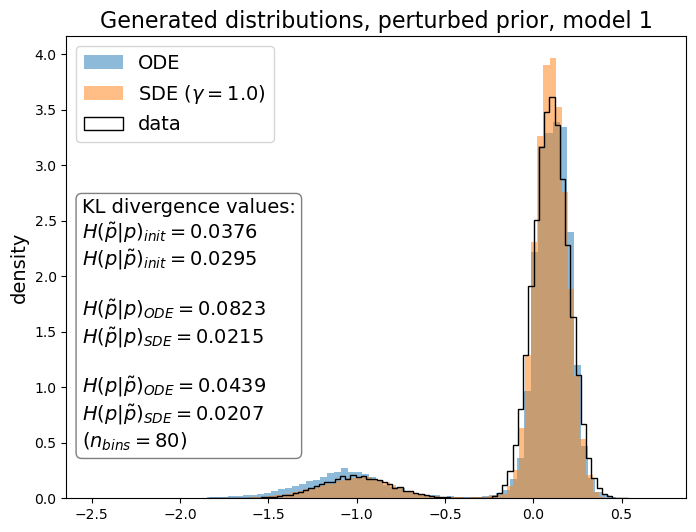

In [89]:
nbins = 80
mod_name = 'model 1'

if case == 'perturbed prior':
    title = f'Generated distributions, perturbed prior, {mod_name}'
elif case == 'different KLs':
    title = f'Generated distributions, default prior, {mod_name}'
else:
    raise ValueError(f'Invalid case: {case}')

plot_figure(ode_samples, sde_samples, data, gamma, nbins=nbins,
            initial_entropy=exact_initial_entropy, initial_inv_entropy=inv_initial_entropy,
            title=title)

In [69]:
# Generate data for comparison
tmin = time[-2]
print(f'Final time: {tmin}')
sigma_min = scheduler.scheduler_fns.noise_fn(tmin)
scale_min = scheduler.scheduler_fns.scaling_fn(tmin)
noise = torch.randn_like(gaussian_samples2) * sigma_min * scale_min

# diffused_gdata2 = scale_min * gaussian_samples2 + noise
# diffused_data = gaussian_samples2

# temporarily change gamma to 1
scheduler.langevin_const = 1

history_steps = nsteps+1-initial_step
forw_sde_history = scheduler.propagate_forward(gaussian_samples2, dataset.gradlogprob, nsteps, record_history=True, stochastic=True)
print(forw_sde_history.shape)
forw_sde_history = forw_sde_history.cpu()
forw_sde_his = forw_sde_history[:history_steps].squeeze(-1)
forw_sde_his = forw_sde_his.flip(0)
forw_sde_his[-1] = data
forw_sde_his.shape

# unchange gamma
scheduler.langevin_const = gamma

Final time: 0.0019999996293336153
torch.Size([501, 100000, 1])


In [70]:
time2 = time[initial_step:]
nbins = 50
ode_entropies, sde_entropies = compute_entropy_evolution(ode_history, sde_history, forw_sde_his, time2, nbins=nbins)

In [71]:
inv_ode_entropies, inv_sde_entropies = compute_entropy_evolution(ode_history, sde_history, forw_sde_his, time2, nbins=nbins, inverseH=True)

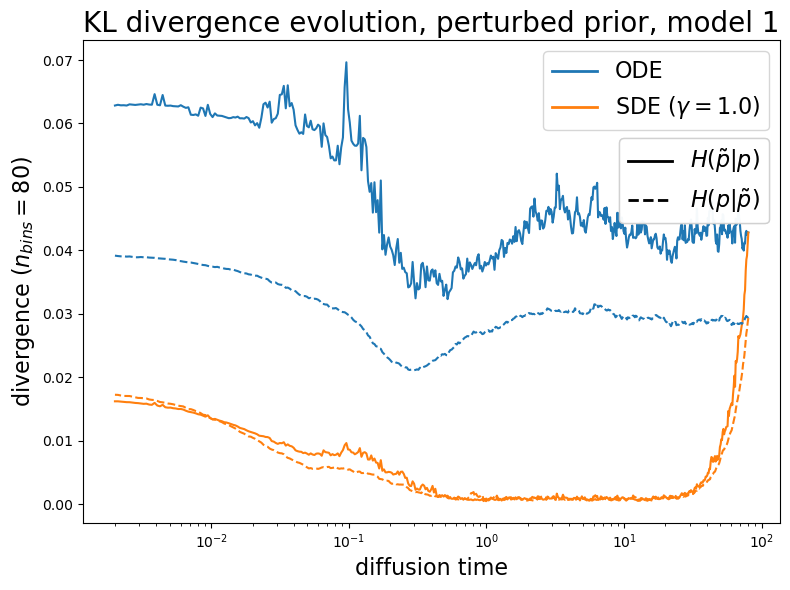

In [88]:
if case == 'perturbed prior':
    title_history = f'KL divergence evolution, perturbed prior, {mod_name}'
elif case == 'different KLs':
    title_history = f'KL divergence evolution, default prior, {mod_name}'
else:
    raise ValueError(f'Invalid case: {case}')

plot_entropy_evolution(ode_entropies[:-1], sde_entropies[:-1], time2[:-1], gamma, initial_time,
                       inv_ode_entropies=inv_ode_entropies[:-1],
                       inv_sde_entropies=inv_sde_entropies[:-1],
                       nbins=nbins,
                       title=title_history,
                       x_logscale=True, y_logscale=False)

In [73]:
# compute theorectical bound for the SDE with approximated scores

def g_squared(t, process):
    if process == 'edm':
        g2 = 2*t
    elif process == 'vp':
        beta_min = 0.1
        beta_d = 19.9
        g2 = beta_d * t + beta_min
    elif process == 've':
        g2 = 1
    return g2


def compute_integral1_discrete(step_initial, step_final, d_values):
    result = 0
    for step in range(step_initial, step_final):
        t = time[step]
        delta = d_values[step - initial_step] * gamma
        if datatype == 'gaussian':
            const = c_gauss(t, m, p, sigma_data)
        elif datatype == 'gaussian2':
            const = c_gauss2(t, m, p, sigma_data)
        if const == float('inf'):
            inv_C = 0
        else:
            inv_C = 1/const
        result += inv_C * g_squared(t, process) * (gamma - delta) * (time[step] - time[step+1])
    return result

def epsilon_norm(step, sde_history, interp_fn, datasize = 2000):
    x = sde_history[step-initial_step, :datasize,].cpu()
    x = x.unsqueeze(-1)
    t = time[step]
    sigma = scheduler.scheduler_fns.noise_fn(t * torch.ones(x.shape[0]))
    x_ = x.to(module.device)
    sigma_ = sigma.to(x_)
    s = scheduler.scheduler_fns.scaling_fn(t)
    score = module.get_score(x_/s, sigma_)
    analytic_score = dataset.gradlogprob(x, sigma).to(score)
    if interp_fn is not None:
        score_dist = torch.mean((interp_fn(t)*(score - analytic_score))**2)
    else:
        score_dist = torch.mean((score - analytic_score)**2)
    return score_dist.detach().cpu().numpy()


def compute_integral2_discrete(initial_step, step_final, tmin, d, sde_history, interp_fn):
    result = 0
    epsilon_ = []
    for step in range(initial_step, step_final):
        t = time[step]
        rev_t = initial_time - t
        if isinstance(d, list):
            integral1 = compute_integral1_discrete(step, step_final, d)
            delta = d[step - initial_step] * gamma
        else:
            raise ValueError('d must be a list of values for each step')
        weight = 1/8 * 1/delta * g_squared(t, process) * (1 + gamma)**2 * np.exp(-integral1)
        epsilon = epsilon_norm(step, sde_history, interp_fn)
        epsilon_.append(epsilon)
        result += weight * epsilon * (time[step] - time[step+1])
    return result, epsilon_

def compute_bound(initial_entropy, d, tmin, history, step_final=nsteps, interp_fn=None):
    if isinstance(d, list):
        integral1 = compute_integral1_discrete(initial_step, step_final, d)
    else:
        raise ValueError('d must be a list of values for each step')
    integral2, score_error = compute_integral2_discrete(initial_step, step_final, tmin, d, history, interp_fn)
    bound = np.exp(-integral1) * initial_entropy + integral2
    return bound, score_error

def _step_dt(step):
    dt = time[step] - time[step + 1]
    return dt.item() if torch.is_tensor(dt) else float(dt)


def inv_C_at_step(step):
    t = time[step]
    if datatype == 'gaussian':
        const = c_gauss(t, m, p, sigma_data)
    elif datatype == 'gaussian2':
        const = c_gauss2(t, m, p, sigma_data)
    else:
        raise ValueError(f'Unsupported datatype: {datatype}')
    return 0 if const == float('inf') else 1 / const


def precompute_bound_coefficients(d_values):
    alphas, coeffs, dts = [], [], []
    for step in range(initial_step, nsteps):
        t = time[step]
        delta = d_values[step - initial_step] * gamma
        inv_C = inv_C_at_step(step)
        dt = _step_dt(step)
        g2 = g_squared(t, process)
        alphas.append(float(inv_C * g2 * (gamma - delta) * dt))
        coeffs.append(float(1 / 8 / delta * g2 * (1 + gamma) ** 2))
        dts.append(dt)
    return alphas, coeffs, dts


def precompute_epsilon_cache(sde_history, interp_fn=None, datasize=2000, verbose=True):
    cache = {}
    steps = range(initial_step, nsteps)
    for i, step in enumerate(steps):
        cache[step] = epsilon_norm(step, sde_history, interp_fn, datasize=datasize)
        if verbose and (i + 1) % 50 == 0:
            print(f'  epsilon cache: {i + 1}/{len(steps)}')
    return cache


def compute_bound_history(initial_entropy, d_values, sde_history, interp_fn=None,
                          datasize=2000, pad=True, verbose=True):
    """Compute bound vs truncation time in O(N) after one pass over score errors."""
    if verbose:
        print('Precomputing score errors...')
    epsilon_cache = precompute_epsilon_cache(
        sde_history, interp_fn, datasize=datasize, verbose=verbose)
    epsilons = [epsilon_cache[step] for step in range(initial_step, nsteps)]

    if verbose:
        print('Computing bound history...')
    alphas, coeffs, dts = precompute_bound_coefficients(d_values)

    A = 0.0
    I2 = 0.0
    bound_history = []
    for step_idx in range(len(alphas)):
        bound_history.append(float(np.exp(-A) * initial_entropy + I2))
        # the new term also carries exp(-integral1) starting at its own step
        I2 = (I2 + coeffs[step_idx] * epsilons[step_idx] * dts[step_idx]) * np.exp(-alphas[step_idx])
        A += alphas[step_idx]

    score_error_history = [epsilons[:k] for k in range(1, len(epsilons) + 1)]
    if pad:
        bound_history.append(float(np.exp(-A) * initial_entropy + I2))
        score_error_history.append(score_error_history[-1])

    return bound_history, score_error_history, epsilons


def _accumulate_bound_final(initial_entropy, alphas, coeffs, dts, epsilons):
    A = 0.0
    I2 = 0.0
    for step_idx in range(len(alphas)):
        I2 = (I2 + coeffs[step_idx] * epsilons[step_idx] * dts[step_idx]) * np.exp(-alphas[step_idx])
        A += alphas[step_idx]
    return float(np.exp(-A) * initial_entropy + I2)


def compute_constant_d_bounds(initial_entropy, d_constants, sde_history, interp_fn=None,
                              datasize=2000, verbose=True):
    """Full bound at nsteps for each constant d, reusing one epsilon cache."""
    n_steps = nsteps - initial_step
    if verbose:
        print('Precomputing score errors for constant-d sweep...')
    epsilon_cache = precompute_epsilon_cache(
        sde_history, interp_fn, datasize=datasize, verbose=verbose)
    epsilons = [epsilon_cache[step] for step in range(initial_step, nsteps)]

    bound_values = []
    for d in d_constants:
        d_values = [d] * n_steps
        alphas, coeffs, dts = precompute_bound_coefficients(d_values)
        bound_values.append(_accumulate_bound_final(initial_entropy, alphas, coeffs, dts, epsilons))
    return bound_values


def precompute_inv_bound_coefficients():
    coeffs, dts = [], []
    for step in range(initial_step, nsteps):
        t = time[step]
        dt = _step_dt(step)
        g2 = g_squared(t, process)
        coeffs.append(float(1 / 8 * g2 * (1 + gamma) ** 2 / gamma))
        dts.append(dt)
    return coeffs, dts


def compute_inv_bound_history(initial_entropy, history, interp_fn=None, datasize=2000,
                              pad=True, verbose=True):
    """Inverse bound vs truncation time in O(N) after one epsilon pass."""
    if verbose:
        print('Precomputing score errors for inverse bound history...')
    epsilon_cache = precompute_epsilon_cache(
        history, interp_fn, datasize=datasize, verbose=verbose)
    epsilons = [epsilon_cache[step] for step in range(initial_step, nsteps)]
    coeffs, dts = precompute_inv_bound_coefficients()

    result = float(initial_entropy)
    inv_bound_history = []
    for step_idx in range(len(epsilons)):
        inv_bound_history.append(result)
        result = result + float(coeffs[step_idx] * epsilons[step_idx] * dts[step_idx])

    if pad:
        inv_bound_history.append(result)
    return inv_bound_history, epsilons


In [74]:
def compute_inv_bound(initial_entropy, history, step_final=nsteps):
    result = initial_entropy
    score_error = []
    for step in range(initial_step, step_final):
        t = time[step]
        epsilon = epsilon_norm(step, history, None)
        score_error.append(epsilon)
        result += 1/8 * g_squared(t, process) * (1 + gamma)**2 /gamma * epsilon * (time[step] - time[step+1])
    return result, score_error

In [75]:
# compute bound
m = 1.1
p = 0.1
sigma_data = [0.2, 0.1]
factor_c = None

In [76]:
d_values = np.linspace(0, 1, 100)
bound_values = compute_constant_d_bounds(
    exact_initial_entropy, d_values, sde_history,
)

Precomputing score errors for constant-d sweep...
  epsilon cache: 50/500
  epsilon cache: 100/500
  epsilon cache: 150/500
  epsilon cache: 200/500
  epsilon cache: 250/500
  epsilon cache: 300/500
  epsilon cache: 350/500
  epsilon cache: 400/500
  epsilon cache: 450/500
  epsilon cache: 500/500


/tmp/ipykernel_338593/70221041.py:684: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sigma = scheduler.scheduler_fns.noise_fn(torch.tensor(t))
/tmp/ipykernel_338593/70221041.py:685: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale = scheduler.scheduler_fns.scaling_fn(torch.tensor(t))
/tmp/ipykernel_338593/70221041.py:687: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  sigma_0 = scale * np.sqrt(sigma**2 + sigma_0**2)
/tmp/ipykernel_338593/70221041.py:688: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  sigma

In [77]:
# grid search for optimal d

def H_deriv_bounds(t, d_values, error, inv_C, H):
    delta_values = d_values * gamma
    bounds = 1/(8*delta_values) * g_squared(t, process) * (1 + gamma)**2 * error
    bounds += - inv_C * g_squared(t, process) * (gamma - delta_values) * H
    return bounds


def delta_finder(sde_history, diffused_history, initial_step, ngrid, interp_fn=None):
    d_values = torch.linspace(0, 1, ngrid)
    opt_d_values = []
    for step in range(initial_step, nsteps):
        t = time[step]
        sde_samples = sde_history[step-initial_step]
        diffused_data = diffused_history[step-initial_step]
        score_error = epsilon_norm(step, sde_history, interp_fn)
        current_entropy = approx_entropy1(sde_samples, diffused_data, nbins=100)

        if datatype == 'gaussian':
            const = c_gauss(t, m, p, sigma_data)
        elif datatype == 'gaussian2':
            const = c_gauss2(t, m, p, sigma_data)
        
        if const == float('inf'):
            inv_C = 0
        else:
            inv_C = 1/const
        
        bounds = H_deriv_bounds(t, d_values, score_error, inv_C, current_entropy)
        opt_d = d_values[np.argmin(bounds)]
        opt_d_values.append(opt_d)
    return opt_d_values

/tmp/ipykernel_338593/70221041.py:684: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sigma = scheduler.scheduler_fns.noise_fn(torch.tensor(t))
/tmp/ipykernel_338593/70221041.py:685: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale = scheduler.scheduler_fns.scaling_fn(torch.tensor(t))
/tmp/ipykernel_338593/70221041.py:687: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  sigma_0 = scale * np.sqrt(sigma**2 + sigma_0**2)
/tmp/ipykernel_338593/70221041.py:688: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  sigma

Text(0.5, 1.0, 'Optimal $d$ values (EDM)')

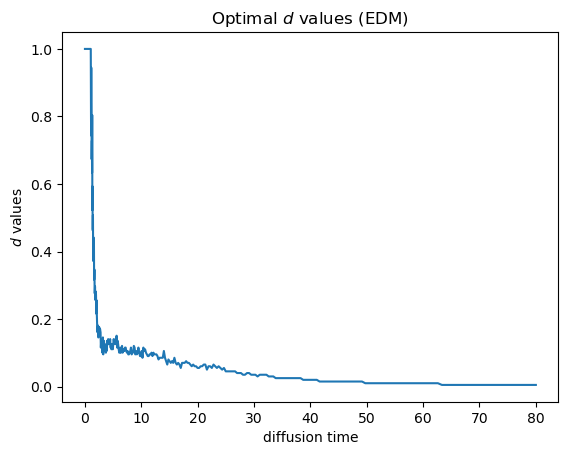

In [78]:
delta_values = delta_finder(sde_history, forw_sde_his, initial_step, 200)

time_plot = time[initial_step:-1].squeeze(-1)
plt.plot(time_plot, delta_values)
plt.xlabel('diffusion time')
plt.ylabel('$d$ values')
plt.title(f'Optimal $d$ values ({process.upper()})')

In [79]:
optimal_bound, _ = compute_bound(exact_initial_entropy, delta_values, tmin, sde_history)

/tmp/ipykernel_338593/70221041.py:684: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sigma = scheduler.scheduler_fns.noise_fn(torch.tensor(t))
/tmp/ipykernel_338593/70221041.py:685: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale = scheduler.scheduler_fns.scaling_fn(torch.tensor(t))
/tmp/ipykernel_338593/70221041.py:687: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  sigma_0 = scale * np.sqrt(sigma**2 + sigma_0**2)
/tmp/ipykernel_338593/70221041.py:688: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  sigma

/tmp/ipykernel_338593/482473186.py:71: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  bound = np.exp(-integral1) * initial_entropy + integral2


Text(0.5, 1.0, 'Approximated scores bound, as a function of $d$')

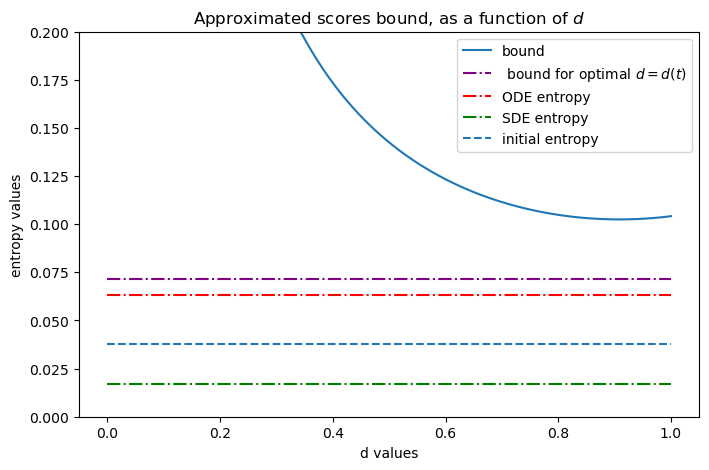

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# plot the bound for approximated scores as a function of d
ax.plot(d_values, bound_values, label='bound')
ax.hlines(optimal_bound, d_values[0], d_values[-1], label=' bound for optimal $d=d(t)$', linestyle='-.', color='purple')
ax.hlines(ode_entropies[-1], d_values[0], d_values[-1], label='ODE entropy', linestyle='-.', color='red')
ax.hlines(sde_entropies[-1], d_values[0], d_values[-1], label='SDE entropy', linestyle='-.', color='green')
ax.hlines(exact_initial_entropy, d_values[0], d_values[-1], label='initial entropy', linestyle='--')
ax.set_ylim(0, 0.2)
ax.set_xlabel('d values')
ax.set_ylabel('entropy values')
ax.legend()
ax.set_title('Approximated scores bound, as a function of $d$')

In [81]:
optimal_bound_history, score_error_history, score_error = compute_bound_history(
    exact_initial_entropy, delta_values, sde_history,
)
print(f'Done: {len(optimal_bound_history)} bound values')

Precomputing score errors...
  epsilon cache: 50/500
  epsilon cache: 100/500
  epsilon cache: 150/500
  epsilon cache: 200/500
  epsilon cache: 250/500
  epsilon cache: 300/500
  epsilon cache: 350/500
  epsilon cache: 400/500
  epsilon cache: 450/500
  epsilon cache: 500/500
Computing bound history...


/tmp/ipykernel_338593/70221041.py:684: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sigma = scheduler.scheduler_fns.noise_fn(torch.tensor(t))
/tmp/ipykernel_338593/70221041.py:685: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale = scheduler.scheduler_fns.scaling_fn(torch.tensor(t))
/tmp/ipykernel_338593/70221041.py:687: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  sigma_0 = scale * np.sqrt(sigma**2 + sigma_0**2)
/tmp/ipykernel_338593/70221041.py:688: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  sigma

Done: 501 bound values


/tmp/ipykernel_338593/70221041.py:692: RuntimeWarning: overflow encountered in exp
  chi_0 = sigma_1**2/(sigma_0 * np.sqrt(2*sigma_1**2 - sigma_0**2)) * np.exp(m2/(2*sigma_1**2 - sigma_0**2))


In [82]:
# compute inverse-bound history
inv_bound_history, score_error_p = compute_inv_bound_history(
    inv_initial_entropy, forw_sde_his,
)
print(f'Done: {len(inv_bound_history)} inverse bound values')

Precomputing score errors for inverse bound history...
  epsilon cache: 50/500
  epsilon cache: 100/500
  epsilon cache: 150/500
  epsilon cache: 200/500
  epsilon cache: 250/500
  epsilon cache: 300/500
  epsilon cache: 350/500
  epsilon cache: 400/500
  epsilon cache: 450/500
  epsilon cache: 500/500
Done: 501 inverse bound values


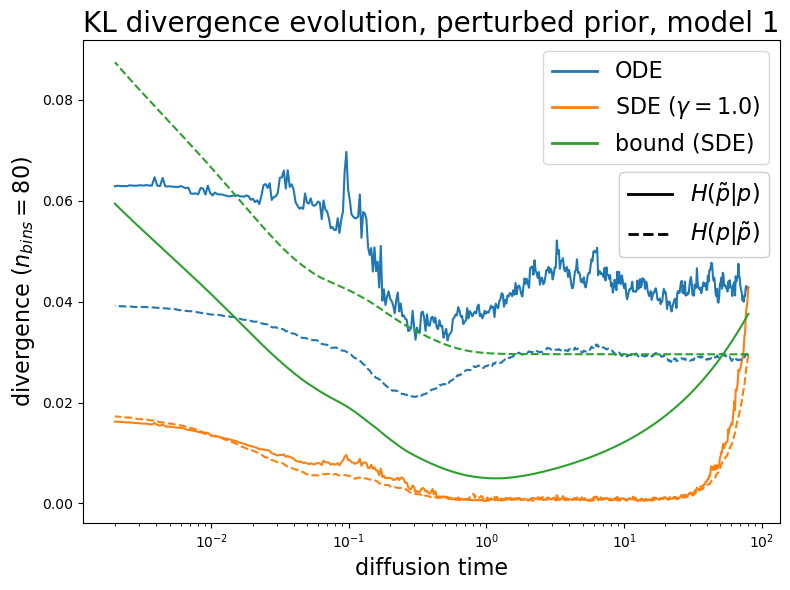

In [90]:
plot_entropy_evolution(ode_entropies[:-1], sde_entropies[:-1], time2[:-1], gamma, initial_time,
                       inv_ode_entropies=inv_ode_entropies[:-1],
                       inv_sde_entropies=inv_sde_entropies[:-1],
                       bound_history=[[optimal_bound_history[:-1], 'optimal $d$'],
                                     [inv_bound_history[:-1], 'inverse bound']],
                       nbins=nbins,
                       title=title_history,
                       x_logscale=True, y_logscale=False)

In [87]:
bound_final = optimal_bound_history[-1]
nbins=80

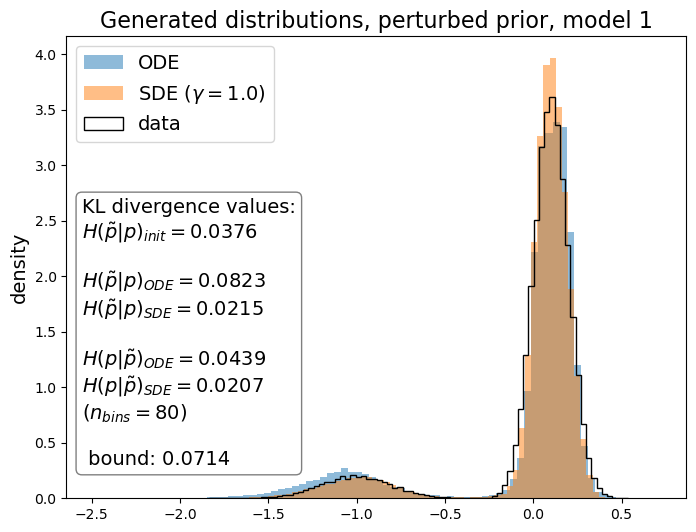

In [91]:
plot_figure(ode_samples, sde_samples, data, gamma, nbins=nbins, bound=bound_final,
            initial_entropy=exact_initial_entropy, title=title)

<!-- Inverse entropy -->

## Colormaps for intervals

<!-- Generate gamma grid for multiple $[S_{min}, S_{max}]$ -->

In [27]:
def generate_multiple_interval(gamma, nsteps, nsamples, dataset, datatype, initial_time, tmin,
                               noisescheduler, module, process, initial_p, exact_p,
                               return_history=False, use_exact_prior=False,
                               checkpoint=None, interval_grid=None, alpha=0.1, ngrid=10):
    if interval_grid is None:
        S_values = custom_spacing(tmin, initial_time, ngrid, alpha=alpha)
        S_values_list = [float(v) for v in S_values]
        interval_grid = list(itertools.product(S_values_list, S_values_list))
    elif len(interval_grid) == ngrid:
        S_values_list = [float(v) for v in interval_grid]
        interval_grid = list(itertools.product(S_values_list, S_values_list))
    elif len(interval_grid) == ngrid * ngrid:
        interval_grid = [(float(a), float(b)) for a, b in interval_grid]
    else:
        raise ValueError(
            f"interval_grid has {len(interval_grid)} entries, expected either "
            f"{ngrid} (1D discretization) or {ngrid * ngrid} (full product grid)")
    print(f'Interval grid built with {len(interval_grid)} entries (ngrid={ngrid})')
    sample_histories = []
    for smin, smax in interval_grid:
        if smin < smax:
            print(f'interval=[{smin}, {smax}]')
            samples_history = generate_samples(
                initial_step, gamma, nsteps, nsamples, dataset, initial_p, exact_p, module=module, sample_type='sde',
                checkpoint=checkpoint, interval=[smin, smax],
                use_exact_prior=use_exact_prior, noisescheduler=noisescheduler,
                save_samples=False)
        else:
            samples_history = None
        sample_histories.append(samples_history)
    
    # save
    if module is not None:
        if checkpoint is None:
            raise ValueError('Checkpoint is required')
        path = pathlib.Path(checkpoint).parent.parent / 'saved_samples'
    else:
        raise ValueError('Module is required')
    path.mkdir(exist_ok=True)
    
    filename = f'trained-nsamples={nsamples:.0e}-nsteps={nsteps}-T={initial_time:.3f}'
    if use_exact_prior:
        filename = 'exact_prior-' + filename
    else:
        filename = 'indep_prior-' + filename
    filename += f'-g={gamma}-interv_grid-T={initial_time:.2f}-{process}'
    if return_history:
        filename += '-his'
    torch.save(sample_histories, path / filename)
    return sample_histories


def plot_general_colormap(samples, ode_samples, diffused_data, initial_time, tmin,
                          nbins=50, ngrid=10, alpha=0.1, title=None, plot_sigma=False,
                          inv_H=False, interval_grid=None, fontsize=16):

    if interval_grid is None:
        S_values = [float(v) for v in custom_spacing(tmin, initial_time, ngrid, alpha=alpha)]
    else:
        if len(interval_grid) == 1 and isinstance(interval_grid[0], (list, tuple)):
            inner = interval_grid[0]
            if len(inner) > 0 and not isinstance(inner[0], (list, tuple)):
                interval_grid = inner
        if len(interval_grid) == 0:
            raise ValueError('interval_grid must not be empty')
        first = interval_grid[0]
        if isinstance(first, (list, tuple)) and len(first) == 2:
            grid = [(float(a), float(b)) for a, b in interval_grid]
            ngrid = int(len(grid) ** 0.5)
            if ngrid * ngrid != len(grid):
                raise ValueError(
                    f"interval_grid has {len(grid)} pair entries, expected a square grid")
            S_values = [grid[i * ngrid][0] for i in range(ngrid)]
        elif len(interval_grid) == ngrid:
            S_values = [float(v) for v in interval_grid]
        else:
            S_values = [float(v) for v in interval_grid]
            ngrid = len(S_values)

    if len(samples) != ngrid * ngrid:
        raise ValueError(
            f"samples has {len(samples)} entries, expected {ngrid * ngrid} "
            f"for an {ngrid}x{ngrid} interval grid")

    sde_entropies = []
    for sample in samples:
        if sample is None:
            sde_entropy = np.nan
        else:
            sample = sample.squeeze(-1)
            if inv_H:
                sde_entropy = approx_entropy1(diffused_data, sample, nbins=nbins)
            else:
                sde_entropy = approx_entropy1(sample, diffused_data, nbins=nbins)
        sde_entropies.append(sde_entropy)
    if inv_H:
        ode_entropy = approx_entropy1(diffused_data, ode_samples, nbins=nbins)
        divergence_label = '$H(p|\~p)$'
    else:
        ode_entropy = approx_entropy1(ode_samples, diffused_data, nbins=nbins)
        divergence_label = '$H(\~p|p)$'
    print(sde_entropies)

    # plot a ngridxngrid colormap/colortable of the entropies
    sde_entropies = torch.tensor(sde_entropies)
    sde_entropies = sde_entropies.reshape(ngrid, ngrid)
    for i in range(ngrid):
            if torch.isnan(sde_entropies[i, i]):
                sde_entropies[i, i] = ode_entropy
            else:
                print(f'for i={i}, entropy={sde_entropies[i, i]:.4f}')
                raise ValueError('Entropy should be nan in the diagonal')
            
    sde_entropies = torch.flip(sde_entropies, dims=(0,))
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    im = ax.imshow(sde_entropies, cmap='viridis')

    # We want to show all ticks...
    ax.set_xticks(np.arange(ngrid))
    ax.set_yticks(np.arange(ngrid))
    # ... and label them with the respective list entries
    x = S_values
    if plot_sigma:
        x = [scheduler.scheduler_fns.noise_fn(t) for t in x]
    x = [f'{v:.3f}' for v in x]
    # x = x[::-1]
    y = x[::-1]
    ax.set_xticklabels(x)
    ax.set_yticklabels(y)
    if plot_sigma:
        ax.set_xlabel('$\sigma(S_{max})$', fontsize=fontsize)
        ax.set_ylabel('$\sigma(S_{min})$', fontsize=fontsize)
    else:
        ax.set_xlabel('$S_{max}$', fontsize=fontsize)
        ax.set_ylabel('$S_{min}$', fontsize=fontsize)
    
    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")
    
    # Loop over data dimensions and create text annotations.
    for i in range(ngrid):
        for j in range(ngrid):
            text = ax.text(j, i, f'{sde_entropies[i, j]:.3f}',
                           ha="center", va="center", color="w",
                           fontsize=12)
    # show colorbar
    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(divergence_label, fontsize=fontsize+2)
    
    ax.set_title(title, fontsize=fontsize+6, pad=20)
    fig.tight_layout()
    plt.show()

    return sde_entropies

<>:98: SyntaxWarning: invalid escape sequence '\~'
<>:101: SyntaxWarning: invalid escape sequence '\~'
<>:131: SyntaxWarning: invalid escape sequence '\s'
<>:132: SyntaxWarning: invalid escape sequence '\s'
<>:98: SyntaxWarning: invalid escape sequence '\~'
<>:101: SyntaxWarning: invalid escape sequence '\~'
<>:131: SyntaxWarning: invalid escape sequence '\s'
<>:132: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2624568/2778303931.py:98: SyntaxWarning: invalid escape sequence '\~'
  divergence_label = '$H(p|\~p)$'
/tmp/ipykernel_2624568/2778303931.py:101: SyntaxWarning: invalid escape sequence '\~'
  divergence_label = '$H(\~p|p)$'
/tmp/ipykernel_2624568/2778303931.py:131: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel('$\sigma(S_{max})$', fontsize=fontsize)
/tmp/ipykernel_2624568/2778303931.py:132: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel('$\sigma(S_{min})$', fontsize=fontsize)


In [28]:
# Define parameters
process = 'edm'

if process == 'edm':
    scheduler = diffsci.models.EDMScheduler()
    initial_time=80
elif process == 'vp':
    scheduler = VPScheduler()
    initial_time=0.21
elif process == 've':
    scheduler = VEScheduler()
    initial_time=0.55
else:
    raise ValueError('Invalid process')

initial_time_ = torch.tensor(initial_time)
nsteps = 500
gamma = 1
nsamples = 100000

initial_step = scheduler.step_from_time(t=initial_time_, n=nsteps)
time = scheduler.create_steps(nsteps+1)
initial_time = time[initial_step].item()
print(f'Initial step: {initial_step}')
print(f'Initial_time: {initial_time}')

Initial step: 0
Initial_time: 80.00001525878906


In [29]:
# Generate data for comparison
tmin = time[-1]
sigma_min = scheduler.scheduler_fns.noise_fn(tmin)
scale_min = scheduler.scheduler_fns.scaling_fn(tmin)
noise = torch.randn_like(gaussian_samples2) * sigma_min * scale_min
diffused_gdata = scale_min * gaussian_samples2 + noise
diffused_gdata = diffused_gdata.squeeze(-1)
diffused_gdata2 = scale_min * gaussian_samples2 + noise
diffused_gdata2 = diffused_gdata2.squeeze(-1)

diffused_data = diffused_gdata2

In [30]:
# generate prior distributions
dataset.num_samples = nsamples
samples = dataset.sample()
sigma = scheduler.scheduler_fns.noise_fn(initial_time_)
scale = scheduler.scheduler_fns.scaling_fn(initial_time_)
initial_p = torch.randn_like(samples) * sigma * scale
exact_p = scheduler.apply_noise(samples, nsteps, initial_step)

exact_prior = False

prior = 'approx_prior'
if exact_prior:
    exact_initial_entropy = 0
    prior = 'exact_prior'

In [31]:
# generate sample histories for different intervals

checkpointpath1 = r"/home/ubuntu/repos/DiffSci/savedmodels/experimental/mixt_gauss2_silu-width=128-bs=16-precond=edm-diffsci-train=4000-nlm=default/checkpoints/sample-epoch=41-valid_loss=0.254058.ckpt"
module1 = KarrasModule.load_from_checkpoint(model=model, config=config, checkpoint_path=checkpointpath1)

checkpointpath2 = r"/home/ubuntu/repos/DiffSci/savedmodels/experimental/mixt_gauss2_silu-width=128-bs=16-precond=edm-diffsci-train=4000-nlm=default2/checkpoints/sample-epoch=47-valid_loss=0.249473.ckpt"
module2 = KarrasModule.load_from_checkpoint(model=model, config=config, checkpoint_path=checkpointpath2)

checkpointpath3 = r"/home/ubuntu/repos/DiffSci/savedmodels/production/mixt_gauss2_silu-width=128-bs=16-precond=edm-default-train=4000-nonres2/checkpoints/sample-epoch=43-valid_loss=0.290424.ckpt"
module3 = KarrasModule.load_from_checkpoint(model=model, config=config, checkpoint_path=checkpointpath3)

module = module1
checkpointpath = checkpointpath1

interval_grid = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0]

# sample_histories = generate_multiple_interval(gamma, nsteps, nsamples, dataset, datatype, initial_time, tmin,
#                     scheduler, module, process, initial_p, exact_p, return_history=True, use_exact_prior=exact_prior,
#                     checkpoint=checkpointpath, interval_grid=interval_grid)

In [70]:
# load saved samples
path1 = r"/home/ubuntu/repos/DiffSci/savedmodels/experimental/mixt_gauss2_silu-width=128-bs=16-precond=edm-diffsci-train=4000-nlm=default/saved_samples/indep_prior-trained-nsamples=1e+05-nsteps=500-T=80.000-g=1-interv_grid-T=80.00-edm-his"
path2 = r"/home/ubuntu/repos/DiffSci/savedmodels/experimental/mixt_gauss2_silu-width=128-bs=16-precond=edm-diffsci-train=4000-nlm=default2/saved_samples/indep_prior-trained-nsamples=1e+05-nsteps=500-T=80.000-g=1-interv_grid-T=80.00-edm-his"
path3 = r"/home/ubuntu/repos/DiffSci/savedmodels/production/mixt_gauss2_silu-width=128-bs=16-precond=edm-default-train=4000-nonres2/saved_samples/indep_prior-trained-nsamples=1e+05-nsteps=500-T=80.000-g=1-interv_grid-T=80.00-edm-his"

path1_5 = r"/home/ubuntu/repos/DiffSci/savedmodels/experimental/mixt_gauss2_silu-width=128-bs=16-precond=edm-diffsci-train=4000-nlm=default/saved_samples/indep_prior-trained-nsamples=1e+05-nsteps=500-T=80.000-g=5-interv_grid-T=80.00-edm-his"
path2_5 = r"/home/ubuntu/repos/DiffSci/savedmodels/experimental/mixt_gauss2_silu-width=128-bs=16-precond=edm-diffsci-train=4000-nlm=default2/saved_samples/indep_prior-trained-nsamples=1e+05-nsteps=500-T=80.000-g=5-interv_grid-T=80.00-edm-his"
path3_5 = r"/home/ubuntu/repos/DiffSci/savedmodels/production/mixt_gauss2_silu-width=128-bs=16-precond=edm-default-train=4000-nonres2/saved_samples/indep_prior-trained-nsamples=1e+05-nsteps=500-T=80.000-g=5-interv_grid-T=80.00-edm-his"

model_num = 3
gamma = 5

if model_num == 1:
    if gamma == 1:
        path = path1
    elif gamma == 5:
        path = path1_5
    else:
        raise ValueError('Invalid gamma')
    module = module1
    checkpointpath = checkpointpath1
elif model_num == 2:
    if gamma == 1:
        path = path2
    elif gamma == 5:
        path = path2_5
    else:
        raise ValueError('Invalid gamma')
    module = module2
    checkpointpath = checkpointpath2
elif model_num == 3:
    if gamma == 1:
        path = path3
    elif gamma == 5:
        path = path3_5
    else:
        raise ValueError('Invalid gamma')
    module = module3
    checkpointpath = checkpointpath3
sample_histories = torch.load(path)

samples = [sample_history[-1] if sample_history is not None else None for sample_history in sample_histories]

/tmp/ipykernel_2624568/3963520909.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample_histories = torch.load(path)


In [71]:
# ode_history = generate_samples(initial_step, gamma, nsteps, nsamples, dataset, module=module,
#                                exact_p=exact_p, initial_p=initial_p, sample_type='ode',
#                                checkpoint=checkpointpath, use_exact_prior=exact_prior,
#                                return_history=True, noisescheduler=scheduler, scheduler_type=process)

In [72]:
# load the pure ODE
ode_path1 = r"/home/ubuntu/repos/DiffSci/savedmodels/experimental/mixt_gauss2_silu-width=128-bs=16-precond=edm-diffsci-train=4000-nlm=default/saved_samples/ode-indep_prior-tr-nsamples=1e+05-nsteps=500-T=80.000-his-EDM"
ode_path2 = r"/home/ubuntu/repos/DiffSci/savedmodels/experimental/mixt_gauss2_silu-width=128-bs=16-precond=edm-diffsci-train=4000-nlm=default2/saved_samples/ode-indep_prior-tr-nsamples=1e+05-nsteps=500-T=80.000-his-EDM"
ode_path3 = r"/home/ubuntu/repos/DiffSci/savedmodels/production/mixt_gauss2_silu-width=128-bs=16-precond=edm-default-train=4000-nonres2/saved_samples/ode-indep_prior-tr-nsamples=1e+05-nsteps=500-T=80.000-his-EDM"

if path == path1:
    ode_path = ode_path1
    model_name = 'Model 1'
elif path == path2:
    ode_path = ode_path2
    model_name = 'Model 2'
elif path == path3:
    ode_path = ode_path3
    model_name = 'Model 3'

ode_history = torch.load(ode_path)
ode_samples = ode_history[-1]

/tmp/ipykernel_2624568/2060530550.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ode_history = torch.load(ode_path)


<>:4: SyntaxWarning: invalid escape sequence '\g'
<>:4: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_2624568/3659951072.py:4: SyntaxWarning: invalid escape sequence '\g'
  nbins=nbins, ngrid=10, alpha=0.3, title=f'{model_name}, $\gamma={gamma}$',


[nan, np.float64(0.016510656038656254), np.float64(0.014537004927387749), np.float64(0.007094100633974615), np.float64(0.005783378352024271), np.float64(0.00636042691929044), np.float64(0.007049138784215486), np.float64(0.007341632807141568), np.float64(0.0068810734355072385), np.float64(0.006750951768916087), nan, nan, np.float64(0.01416718278413865), np.float64(0.00684966136665826), np.float64(0.006417873278150397), np.float64(0.008545639979887743), np.float64(0.006808797592860629), np.float64(0.007081512819829837), np.float64(0.0067895828312143575), np.float64(0.007314717156853667), nan, nan, nan, np.float64(0.0075552865062870934), np.float64(0.007915842850883455), np.float64(0.008088894937471839), np.float64(0.006845786447421137), np.float64(0.008073141791888536), np.float64(0.007048874719785669), np.float64(0.007333622373692794), nan, nan, nan, nan, np.float64(0.00541094034220378), np.float64(0.005853375572551204), np.float64(0.006286290197435928), np.float64(0.006079077096814675)

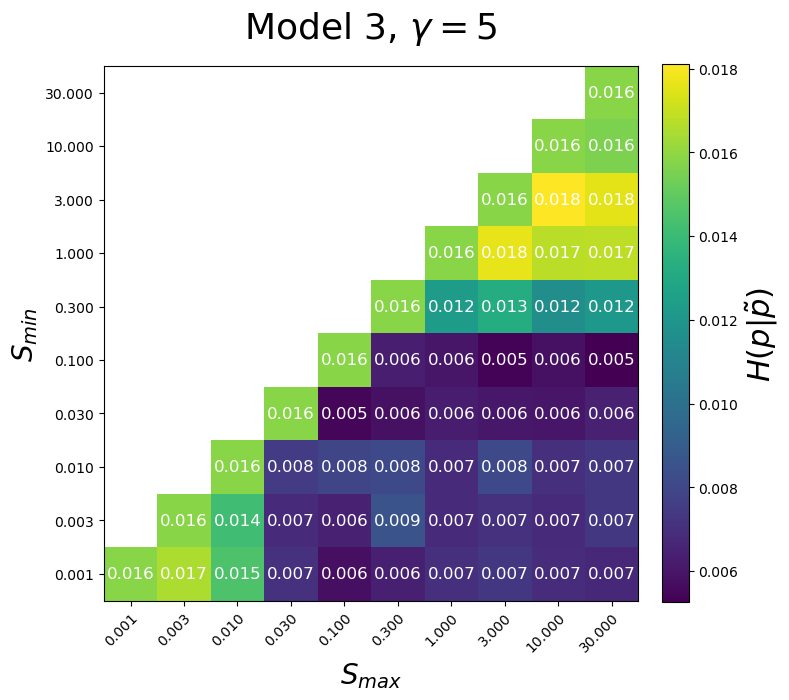

tensor([[   nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
         0.0158],
        [   nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan, 0.0158,
         0.0156],
        [   nan,    nan,    nan,    nan,    nan,    nan,    nan, 0.0158, 0.0181,
         0.0176],
        [   nan,    nan,    nan,    nan,    nan,    nan, 0.0158, 0.0176, 0.0168,
         0.0168],
        [   nan,    nan,    nan,    nan,    nan, 0.0158, 0.0123, 0.0132, 0.0116,
         0.0121],
        [   nan,    nan,    nan,    nan, 0.0158, 0.0063, 0.0060, 0.0054, 0.0058,
         0.0053],
        [   nan,    nan,    nan, 0.0158, 0.0054, 0.0059, 0.0063, 0.0061, 0.0061,
         0.0064],
        [   nan,    nan, 0.0158, 0.0076, 0.0079, 0.0081, 0.0068, 0.0081, 0.0070,
         0.0073],
        [   nan, 0.0158, 0.0142, 0.0068, 0.0064, 0.0085, 0.0068, 0.0071, 0.0068,
         0.0073],
        [0.0158, 0.0165, 0.0145, 0.0071, 0.0058, 0.0064, 0.0070, 0.0073, 0.0069,
         0.0068]], dtype=tor

In [74]:
nbins = 50
inv_H = True
plot_general_colormap(samples, ode_samples, diffused_data, initial_time, tmin, plot_sigma=False,
                      nbins=nbins, ngrid=10, alpha=0.3, title=f'{model_name}, $\gamma={gamma}$',
                      interval_grid=interval_grid, fontsize=20, inv_H=inv_H)